# Восстановление сети Петри и параметров временных распределений: журнал Sepsis

Копия `petri_net_time_estimation.ipynb`, но вместо синтетического генератора используется
реальный журнал **Sepsis Cases** из `Med_Eremina/Sepsis Cases - Event Log_grouped.csv`.
Методы оценки (совместная MLE вероятностей выбора и параметров времени с учётом правой
цензуры, сеть состояний, Inductive Miner, Каплан–Майер) перенесены без изменений.

**Что изменилось по сравнению с синтетическим ноутбуком.**

* Состояния — группы событий `event_group` (Registration, Examination, Treatment,
  Admission, Discharge); соседние повторы одной группы схлопываются, как у Ереминой.
* Терминальное событие — первая выписка `Discharge` (Release A–E). События после неё,
  включая `Return ER`, отбрасываются. Трассы, которые закончились до выписки, — правая цензура.
* Истины нет. Семейство распределения каждого ребра выбирается по AIC,
  а раздел 5 вместо сравнения с истиной измеряет устойчивость оценок на подвыборках
  относительно оценки на всём обучающем журнале и качество на отложенных трассах.

In [1]:
import math
from collections import Counter
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from IPython.display import display

## 1. Журнал Sepsis и состояния модели

Предобработка одной трассы:

1. сортировка событий по времени (при равных timestamp — порядок файла);
2. отсчёт от первой регистрации `Registration`; события до неё отбрасываются,
   трассы без регистрации исключаются;
3. обрезка после первой `Discharge` — это «событие»;
4. схлопывание соседних повторов группы: время входа в состояние — первое событие серии;
5. интервалы с одинаковыми timestamp (0 секунд) заменяются на 1 минуту,
   иначе плотности lognormal/weibull/gamma в нуле не определены.

Если трасса не дошла до `Discharge`, её последнее ожидание цензурировано: известно лишь,
что состояние длилось не меньше, чем от входа в него до последней записи трассы.
Причину обрыва записи журнал не сообщает, поэтому у всех цензурированных трасс
причина `lost` («запись оборвалась»); причины `study_end` здесь нет.
Время храним в днях.

In [2]:
STATE_COLUMN = "event_group"
START = "Registration"   # отсчёт времени — первая регистрация в приёмном отделении
TERMINAL = "Discharge"   # поглощающее состояние = «событие» (выписка Release A–E)
CENSORED = "CENS"
MIN_INTERVAL_DAYS = 1 / 1440   # одинаковые timestamp → интервал 1 минута
SEED = 2026

data_dir = next(p for p in [Path("../Med_Eremina"), Path("Med_Eremina")] if p.exists())
notebook_dir = Path.cwd() if Path("petri_net_time_estimation_sepsis.ipynb").exists() else Path.cwd() / "dima"
OUTPUT_DIR = notebook_dir / "notebooks" / "output" / "sepsis_time_estimation"

raw = pd.read_csv(data_dir / "Sepsis Cases - Event Log_grouped.csv", encoding="utf-8-sig")
raw["timestamp"] = pd.to_datetime(raw["time:timestamp"], utc=True)
raw = raw.sort_values(["case_id", "timestamp"], kind="stable")


def prepare_log(raw):
    event_rows, case_rows = [], []
    for case_id, group in raw.groupby("case_id", sort=True):
        starts = np.flatnonzero(group[STATE_COLUMN].to_numpy() == START)
        if not len(starts):
            continue
        group = group.iloc[starts[0]:]
        ends = np.flatnonzero(group[STATE_COLUMN].to_numpy() == TERMINAL)
        if len(ends):
            group = group.iloc[:ends[0] + 1]
        states = group[STATE_COLUMN].to_numpy()
        days = ((group["timestamp"] - group["timestamp"].iloc[0]).dt.total_seconds() / 86400).to_numpy()
        keep = np.r_[True, states[1:] != states[:-1]]
        gaps = np.maximum(np.diff(days[keep]), MIN_INTERVAL_DAYS)
        offsets = np.r_[0., np.cumsum(gaps)]
        event = int(states[-1] == TERMINAL)
        # Цензура: последнее состояние длилось не меньше, чем до последней записи трассы.
        duration = offsets[-1] if event else offsets[-1] + max(days[-1] - days[keep][-1], MIN_INTERVAL_DAYS)
        entry = group["timestamp"].iloc[0]
        previous_state = None
        for state, t, gap in zip(states[keep], offsets, np.r_[0., gaps]):
            event_rows.append({
                "case_id": case_id,
                "activity": state,
                "timestamp": entry + pd.to_timedelta(t, unit="D").round("s"),
                "transition": "start" if previous_state is None else f"{previous_state}→{state}",
                "duration_days": gap,
            })
            previous_state = state
        case_rows.append({
            "case_id": case_id,
            "entry": entry,
            "duration": duration,
            "event": event,
            "censor_reason": "" if event else "lost",
            "last_state": states[-1],
            "n_events": int(keep.sum()),
        })
    return pd.DataFrame(event_rows), pd.DataFrame(case_rows)


log, cases = prepare_log(raw)
print(f"Трасс в файле: {raw.case_id.nunique()}; без регистрации исключено: "
      f"{raw.case_id.nunique() - len(cases)}; в модели: {len(cases)}")
print(f"Событий после схлопывания: {len(log)}; дошли до {TERMINAL}: {cases.event.mean():.1%}")
display(cases.groupby("last_state").size().rename("n_cases").to_frame())

Трасс в файле: 1049; без регистрации исключено: 0; в модели: 1049
Событий после схлопывания: 5866; дошли до Discharge: 74.5%


,n_cases
last_state,
Admission,13
Discharge,781
Examination,119
Registration,36
Treatment,100


In [3]:
# Функции семейств распределений — как в исходном ноутбуке.
def sample_time(dist, rng):
    kind, par = dist
    if kind == "exponential":
        return rng.exponential(par["mean"])
    if kind == "lognormal":
        return rng.lognormal(np.log(par["median"]), par["sigma"])
    if kind == "gamma":
        return rng.gamma(par["shape"], par["scale"])
    if kind == "weibull":
        return par["scale"] * rng.weibull(par["shape"])
    if kind == "uniform":
        return rng.uniform(par["low"], par["high"])
    raise ValueError(f"неизвестное распределение: {kind}")


def mean_time(dist):
    kind, par = dist
    if kind == "exponential":
        return par["mean"]
    if kind == "lognormal":
        return par["median"] * math.exp(par["sigma"] ** 2 / 2)
    if kind == "gamma":
        return par["shape"] * par["scale"]
    if kind == "weibull":
        return par["scale"] * math.gamma(1 + 1 / par["shape"])
    if kind == "uniform":
        return (par["low"] + par["high"]) / 2
    raise ValueError(f"неизвестное распределение: {kind}")


def dist_str(dist):
    kind, par = dist
    return kind + "(" + ", ".join(f"{k}={v:g}" for k, v in par.items()) + ")"

## 2. Интервалы и правое цензурирование

Каждая пара соседних состояний даёт завершённый интервал $(s,d,t)$.
У цензурированной трассы добавляем **один** последний интервал:
его начало — последнее наблюдаемое состояние, длительность — время от входа
в это состояние до последней записи трассы.
Следующее состояние неизвестно (`dst=None`), даже если семейства распределений известны.
Предшествующие завершённые интервалы цензурированной трассы также используем.

Длительность последнего интервала вычисляем как `cases.duration - sum(duration_days)`.
Не используем округлённые timestamp.

In [4]:
def make_intervals(log, cases):
    previous = log.groupby("case_id", sort=False)["activity"].shift()
    completed = log.loc[previous.notna(), ["case_id", "activity", "duration_days"]].copy()
    completed["src"] = previous.loc[previous.notna()].to_numpy()
    completed = completed.rename(columns={"activity": "dst", "duration_days": "duration"})
    completed["observed"] = True
    completed["reason"] = ""

    elapsed = log.groupby("case_id", sort=False)["duration_days"].sum()
    censored = cases.loc[cases["event"] == 0].copy()
    censored["duration"] -= censored["case_id"].map(elapsed)
    assert (censored["duration"] >= -1e-9).all(), "Отрицательный последний интервал"
    censored["duration"] = censored["duration"].clip(lower=0)
    censored = censored.rename(columns={"last_state": "src", "censor_reason": "reason"})
    censored["dst"] = None
    censored["observed"] = False
    columns = ["case_id", "src", "dst", "duration", "observed", "reason"]
    return pd.concat([completed[columns], censored[columns]], ignore_index=True)

In [5]:
intervals = make_intervals(log, cases)
assert np.isclose(intervals["duration"].sum(), cases["duration"].sum())
print(f"Завершённых интервалов: {intervals.observed.sum()}; "
      f"цензурированных интервалов: {(~intervals.observed).sum()}")
display(intervals.head(10))
edge_summary = (intervals.loc[intervals.observed].groupby(["src", "dst"]).duration
                .agg(["count", "median", "mean", "max"]))
display(edge_summary.round(4))

Завершённых интервалов: 4817; цензурированных интервалов: 268


,case_id,src,dst,duration,observed,reason
0,A,Registration,Examination,0.007859,True,
1,A,Examination,Treatment,0.108877,True,
2,A,Treatment,Admission,0.006620,True,
3,A,Admission,Examination,1.782419,True,
4,A,Examination,Discharge,9.302083,True,
5,AA,Registration,Examination,0.017546,True,
6,AA,Examination,Treatment,0.205521,True,
7,AAA,Registration,Treatment,0.002280,True,
8,AAA,Treatment,Examination,0.016227,True,
9,AAA,Examination,Treatment,0.083762,True,


count  median    mean      max
src          dst                                        
Admission    Discharge      139  2.9014  3.3703  15.7372
             Examination    915  1.0570  1.3262   7.8008
             Treatment       29  0.7948  0.5725   0.9661
Examination  Admission      498  0.1778  1.4493  35.8318
             Discharge      636  3.8628  5.4639  62.0833
             Treatment      705  0.0667  0.0768   0.6840
Registration Admission        7  0.1025  0.1195   0.2559
             Examination    758  0.0167  0.0195   0.1355
             Treatment      248  0.0103  0.0138   0.2646
Treatment    Admission      591  0.0279  0.0533   1.7634
             Discharge        6  2.4686  2.5132   5.5398
             Examination    285  0.0083  0.1195   5.6244

## 3. Совместная оценка вероятностей и параметров времени

**Что мы хотим узнать.** Модель предполагает, что после входа объекта в состояние сначала выбирается
следующий переход, затем генерируется его время. Например, из `Admission` возможны
`Admission→Examination`, `Admission→Treatment` и `Admission→Discharge`. По журналу нужно оценить одновременно две вещи:

* как часто заранее выбирается каждый выход — вероятности `p`, подписанные
  на схеме как `π выбор`;
* как долго длится выбранный переход — параметры его распределения времени.

«Совместная» означает, что оптимизатор подбирает эти числа **вместе для всех выходов
одного состояния**. Выходы каждого состояния оцениваются отдельными задачами.
Истинные параметры реального журнала неизвестны. Семейство распределения каждого
ребра выбирается заранее по AIC (раздел 3.1) и далее считается фиксированным;
его параметры оцениваются.

**Какие наблюдения используются.**

| Запись | Что известно | Что она сообщает оценивателю |
|---|---|---|
| Завершился `A→B` за 2 дня | Начало, конец и точное время | Был выбран B, и длительность равна 2 дням |
| Объект потерян после 5 дней ожидания в A | Начало и нижняя граница времени | Выбранный выход из A не завершился за 5 дней; его конец неизвестен |

Все завершённые интервалы цензурированной трассы сохраняются. Только её последнее
ожидание считается незавершённым. Петли дают дополнительные наблюдения при каждом
посещении состояния; распределение одного ребра считается одинаковым для всех посещений.

**Почему нельзя сначала просто посчитать частоты, а потом средние времена.**
Медленный переход чаще не успевает завершиться до потери наблюдения или конца
исследования. Среди записанных завершений он встречается реже, чем среди
предварительных выборов. Если выбросить цензуру, мы одновременно исказим частоты
выходов и распределения длительности.

У незавершённого ожидания возможны два объяснения: часто выбирается медленный
выход либо само распределение времени имеет длинный хвост. Чтобы сопоставить
оба объяснения с завершёнными наблюдениями, вероятности и времена нужно оценивать
в одной задаче. На маленькой выборке несколько объяснений могут быть почти
равно правдоподобны, поэтому совместная оценка не гарантирует точности.

**Шаг 1. Предлагаем некоторый набор параметров.**
Для каждого выхода из состояния задаём вероятность $p_{sd}$ и параметры
$\theta_{sd}$. Вероятности должны давать единицу: $\sum_d p_{sd}=1$.
Этот набор — кандидат, который оптимизатор затем будет менять.

Для распределения времени используются две функции:

* $f_{sd}(t;\theta)$ — плотность завершения около времени $t$;
* $S_{sd}(t;\theta)=P(T_{sd}>t)$ — вероятность, что выбранный переход
  не завершится за $t$ дней.

**Шаг 2. Оцениваем согласованность кандидата с завершёнными интервалами.**
Если записан переход $s→d$ за $t$ дней, его вклад в правдоподобие:

$$L_{\mathrm{completed}}=p_{sd}\,f_{sd}(t;\theta_{sd}).$$

Первый множитель отвечает за выбор нужного направления, второй — за наблюдаемую
длительность. Плотность не является вероятностью одной точной длительности;
это множитель для сравнения кандидатов по непрерывным наблюдениям.

**Шаг 3. Оцениваем согласованность с цензурированными интервалами.**
Если ожидание из $s$ оборвалось через $c$ дней, известно только $T>c$.
Следующее состояние скрыто, поэтому складываем возможные объяснения:

$$L_{\mathrm{censored}}=\sum_d p_{sd}\,S_{sd}(c;\theta_{sd}).$$

Каждый выход участвует со своей вероятностью выбора и своей вероятностью
долгого ожидания. Цензурированный интервал не приписывается одному конкретному
ребру и не считается точным временем завершения.

**Числовой пример смеси.** Возьмём учебное состояние X с двумя выходами
(это пример для формулы):

| Выход | Предложенная вероятность | Предложенное время |
|---|---|---|
| X→Y | 0,7 | exponential со средним 2 дня |
| X→Z | 0,3 | exponential со средним 8 дней |

Для exponential $S(c)=e^{-c/\mu}$. Если наблюдение оборвалось после 5 дней:

$$S_{XY}(5)=e^{-5/2}\approx0.0821,\qquad
S_{XZ}(5)=e^{-5/8}\approx0.5353.$$

Вклад этого интервала:

$$L_{\mathrm{censored}}=
0.7\cdot0.0821+0.3\cdot0.5353\approx0.2180.$$

Медленный выход объясняет большую часть этого вклада. При таком кандидате
условная вероятность выбора Z после известного факта $T>5$ равна примерно 74%:

$$P(J=Z\mid T>5)=
\frac{0.3\cdot0.5353}{0.2180}\approx0.74.$$

Это не восстановленный факт о конкретной трассе: другой кандидат даст другие
веса. Код не назначает ей Z, а сохраняет сумму двух вариантов в правдоподобии.
Если увеличить вероятность медленного выхода или его среднее время, этот
цензурированный интервал станет легче объяснить. Но новый кандидат должен
также хорошо объяснять все завершённые переходы с известными направлениями
и временами — они ограничивают такие изменения.

**Шаг 4. Объединяем все наблюдения и ищем лучший кандидат.**
Правдоподобие источника — произведение вкладов всех его ожиданий. Для вычислений
используем логарифм: произведение превращается в сумму, а очень маленькие числа
не перемножаются напрямую. Для состояния $s$:

$$\ell_s=
\sum_{i:\delta_i=1}
\left[\log p_{s,d_i}+\log f_{s,d_i}(t_i;\theta_{s,d_i})\right]
+\sum_{j:\delta_j=0}
\log\left[\sum_d p_{sd}S_{sd}(c_j;\theta_{sd})\right].$$

Здесь $\delta=1$ означает завершённый интервал, $\delta=0$ — цензурированный.
Оптимизатор `scipy.optimize.minimize` минимизирует $-\ell_s$: это эквивалентно
максимизации правдоподобия. В коде цель делится на число интервалов данного
источника, что не меняет положения оптимума.

Практически процедура выглядит так: получить начальные оценки по завершениям,
посчитать цель, изменить вероятности и временные параметры, снова посчитать
цель и продолжать до остановки оптимизатора. Используется L-BFGS-B с ограничениями
и два начальных приближения. Это численный поиск, а не перебор всех наборов;
глобальный максимум не гарантируется.

Для сохранения ограничений положительные параметры задаются через экспоненту,
а вероятности — через softmax, который нормирует их сумму к единице.
Для uniform `low=min(наблюдаемых времён)`, а `high` оптимизируется выше
наблюдаемого максимума. Для остальных семейств фиксируем `loc=0`.

**Как здесь учитывается механизм цензуры.** Предполагается, что прекращение
наблюдения независимо от скрытого времени выбранного перехода условно
на наблюдаемую историю. Тогда множители механизма цензуры не зависят от
оцениваемых $p,\theta$ и могут быть опущены. Поэтому механизм цензуры
моделировать не нужно. При зависимой цензуре такое правдоподобие
может дать неверные оценки.

**Что получаем в результате.** Для каждого успешно оценённого ребра —
`p` и `dist`, например оценённую медиану и `sigma` lognormal. Среднее время
затем вычисляется по формуле этого семейства. Вероятности ухода в `CENS`
на рисунке (`q наблюд.`) считаются отдельно как наблюдаемые частоты;
они не входят в сумму предварительных вероятностей $\sum_d p_{sd}=1$.

**Наивная оценка для сравнения** использует только завершённые интервалы:
в её цели отсутствует сумма по цензуре. При большом объёме данных она может
сходиться к устойчивым, но смещённым параметрам.

**Малые выборки.** Включаем только пары, хотя бы раз наблюдавшиеся в журнале.
Ненаблюдавшиеся переходы не добавляем. Для exponential требуется
хотя бы одно завершение, для остальных семейств — три. Если хотя бы один
обнаруженный выход источника не достигает этого минимума, весь набор выходов
источника получает `insufficient_data`, параметры не выдаются. Этот технический
порог не является гарантией надёжности. Статус численного поиска и попадание
на границы сохраняются в `diagnostics`.

In [6]:
PARAMETERS = {
    "exponential": ("mean",), "lognormal": ("median", "sigma"),
    "gamma": ("shape", "scale"), "weibull": ("shape", "scale"),
    "uniform": ("low", "high"),
}


def scipy_args(dist):
    kind, par = dist
    if kind == "exponential":
        return stats.expon, (), dict(scale=par["mean"])
    if kind == "lognormal":
        return stats.lognorm, (par["sigma"],), dict(scale=par["median"])
    if kind == "gamma":
        return stats.gamma, (par["shape"],), dict(scale=par["scale"])
    if kind == "weibull":
        return stats.weibull_min, (par["shape"],), dict(scale=par["scale"])
    if kind == "uniform":
        return stats.uniform, (), dict(loc=par["low"], scale=par["high"] - par["low"])
    raise ValueError(kind)


def initial_dist(kind, x):
    if kind == "exponential":
        par = dict(mean=x.mean())
    elif kind == "lognormal":
        par = dict(median=np.exp(np.log(x).mean()), sigma=max(np.log(x).std(), .05))
    elif kind == "gamma":
        shape, _, scale = stats.gamma.fit(x, floc=0)
        par = dict(shape=shape, scale=scale)
    elif kind == "weibull":
        shape, _, scale = stats.weibull_min.fit(x, floc=0)
        par = dict(shape=shape, scale=scale)
    elif kind == "uniform":
        par = dict(low=x.min(), high=x.max())
    else:
        raise ValueError(kind)
    return kind, par


def source_nll(intervals, edges, probabilities, distributions):
    """Отрицательный log-likelihood; у цензуры скрытый конец суммируется."""
    result, survival_terms = 0., []
    censored = intervals.loc[~intervals["observed"], "duration"].to_numpy()
    for edge, p, dist in zip(edges, probabilities, distributions):
        rv, args, kwargs = scipy_args(dist)
        x = intervals.loc[intervals["observed"] & (intervals["dst"] == edge[1]),
                          "duration"].to_numpy()
        result -= len(x) * np.log(p) + rv.logpdf(x, *args, **kwargs).sum()
        survival_terms.append(np.log(p) + rv.logsf(censored, *args, **kwargs))
    if len(censored):
        result -= logsumexp(np.array(survival_terms), axis=0).sum()
    return float(result)


def fit_source(intervals, families, use_censoring=True):
    """Восстанавливает обнаруженные выходы одного состояния; истина не передаётся."""
    completed = intervals.loc[intervals["observed"]]
    source = intervals["src"].iloc[0]
    destinations = sorted(completed["dst"].unique())
    edges = [(source, dst) for dst in destinations]
    counts = completed.groupby("dst").size()
    diagnostic = dict(src=source, success=False, status="insufficient_data",
                      n_completed=len(completed), n_censored=int((~intervals.observed).sum()))
    if not edges or any(counts[edge[1]] < (1 if families[edge] == "exponential" else 3)
                        for edge in edges):
        return [], diagnostic
    data = intervals if use_censoring else completed
    initial = [initial_dist(families[edge], completed.loc[completed.dst == edge[1],
                                                       "duration"].to_numpy()) for edge in edges]
    k = len(edges)
    p0 = counts.reindex(destinations).to_numpy() / len(completed)
    x0 = list(np.log(p0[:-1] / p0[-1]))
    bounds = [(-15., 15.)] * (k - 1)
    for kind, par in initial:
        if kind == "uniform":
            width = par["high"] - par["low"]
            # Положительный старт survival даже если цензура позже максимума завершений.
            cens = data.loc[~data.observed, "duration"]
            extra = max(width * .1, cens.max() - par["high"] + .1) if len(cens) else width * .1
            x0.append(np.log(extra / width))
            bounds.append((-20., 12.))
        else:
            x0.extend(np.log([par[name] for name in PARAMETERS[kind]]))
            bounds.extend([(-5., 5.) if name in ("shape", "sigma") else (-15., 15.)
                           for name in PARAMETERS[kind]])

    def decode(vector):
        probabilities = softmax(np.r_[vector[:k - 1], 0.])
        distributions, offset = [], k - 1
        for kind, par in initial:
            if kind == "uniform":
                high = par["high"] + (par["high"] - par["low"]) * np.exp(vector[offset])
                distributions.append((kind, dict(low=par["low"], high=high)))
                offset += 1
            else:
                names = PARAMETERS[kind]
                values = np.exp(vector[offset:offset + len(names)])
                distributions.append((kind, dict(zip(names, values))))
                offset += len(names)
        return probabilities, distributions

    def objective(vector):
        p, distributions = decode(vector)
        value = source_nll(data, edges, p, distributions) / len(data)
        return value if np.isfinite(value) else 1e100

    attempts = []
    for shift in (0., .15):
        start = np.clip(np.array(x0) + shift, np.array(bounds)[:, 0], np.array(bounds)[:, 1])
        attempts.append(minimize(objective, start, method="L-BFGS-B", bounds=bounds,
                                 options=dict(maxiter=500, ftol=1e-10, gtol=1e-6)))
    valid = [r for r in attempts if r.success and np.isfinite(r.fun) and r.fun < 1e90]
    best = min(valid or attempts, key=lambda r: r.fun)
    boundary = any(abs(v - lo) < 1e-4 or abs(v - hi) < 1e-4
                   for v, (lo, hi) in zip(best.x, bounds))
    diagnostic.update(success=bool(valid), status="ok" if valid else "optimizer_failed",
                      nll=float(best.fun * len(data)), message=str(best.message),
                      at_boundary=boundary)
    if not valid:
        return [], diagnostic
    probabilities, distributions = decode(best.x)
    rows = [dict(src=edge[0], dst=edge[1], name=f"{edge[0]}→{edge[1]}",
                 p=float(p), dist=dist, n_completed=int(counts[edge[1]]))
            for edge, p, dist in zip(edges, probabilities, distributions)]
    return rows, diagnostic


def estimate_network(intervals, families, use_censoring=True):
    rows, diagnostics = [], []
    for _, group in intervals.groupby("src", sort=True):
        estimated, diagnostic = fit_source(group, families, use_censoring)
        rows.extend(estimated)
        diagnostics.append(diagnostic)
    return rows, pd.DataFrame(diagnostics)

### 3.1 Выбор семейства распределения по AIC

Для каждого ребра подбираем по завершённым интервалам MLE четырёх семейств —
exponential, lognormal, gamma, weibull — и выбираем минимальный
$\mathrm{AIC}=2k-2\log L$. Uniform исключён: на реальных длительностях он не правдоподобен.
Если завершений меньше трёх, берём exponential (минимум оценивателя для других семейств).

Выбор делается по завершённым интервалам, без учёта цензуры: это быстрый
предварительный шаг. Дальше семейства фиксированы, а параметры оцениваются
совместной MLE с цензурой.

In [7]:
CANDIDATE_FAMILIES = ["exponential", "lognormal", "gamma", "weibull"]


def family_aic(x):
    rows = []
    for kind in CANDIDATE_FAMILIES:
        rv, args, kwargs = scipy_args(initial_dist(kind, x))
        loglik = rv.logpdf(x, *args, **kwargs).sum()
        rows.append(dict(family=kind, aic=2 * len(PARAMETERS[kind]) - 2 * loglik))
    return rows


aic_rows = []
for (src, dst), group in intervals.loc[intervals.observed].groupby(["src", "dst"]):
    x = group.duration.to_numpy()
    rows = family_aic(x) if len(x) >= 3 else [dict(family="exponential", aic=np.nan)]
    aic_rows.extend(dict(src=src, dst=dst, n_completed=len(x), **row) for row in rows)
aic_table = pd.DataFrame(aic_rows)
aic_table["delta_aic"] = aic_table.aic - aic_table.groupby(["src", "dst"]).aic.transform("min")
best_families = aic_table.sort_values("aic", na_position="last").groupby(["src", "dst"]).head(1)
FAMILIES = {(row.src, row.dst): row.family for row in best_families.itertuples()}
display(aic_table.pivot_table(index=["src", "dst", "n_completed"], columns="family",
                              values="delta_aic").round(1))
display(pd.Series(FAMILIES, name="family").to_frame())

family                                exponential  gamma  lognormal  weibull
src          dst         n_completed                                        
Admission    Discharge   139                 20.1    1.4       40.3      0.0
             Examination 915                 30.0    4.8      228.1      0.0
             Treatment   29                  13.3    0.0       18.9      6.0
Examination  Admission   498                596.0  239.1        0.0    125.7
             Discharge   636                  8.0    0.0       52.5      5.7
             Treatment   705                 12.0    0.0      172.6      6.0
Registration Admission   7                    0.0    0.3        0.6      0.2
             Examination 758                397.7   31.3        0.0    105.3
             Treatment   248                 39.9   33.1        0.0     41.4
Treatment    Admission   591                446.0    0.0       28.4     12.1
             Discharge   6                    0.0    0.8        4.7      1.4
             Examination 285                803.1  287.0        0.0    141.5

,,family
Registration,Examination,lognormal
Treatment,Admission,gamma
Examination,Treatment,gamma
Registration,Treatment,lognormal
Treatment,Examination,lognormal
Registration,Admission,exponential
Admission,Treatment,gamma
Treatment,Discharge,exponential
Admission,Discharge,weibull
Examination,Admission,lognormal


### 3.2 Проверки оценивателя

Для одного экспоненциального перехода с правой цензурой MLE среднего равна
суммарной экспозиции / числу завершений. Без цензуры — обычному среднему.
Это проверка формулы, независимая от оптимизатора. Дополнительно проверяем,
что цензурированный интервал не приписывается конкретному переходу.

In [8]:
check = pd.DataFrame(dict(src=["A"] * 5, dst=["B", "B", "B", None, None],
                          duration=[2., 4., 3., 3., 5.], observed=[True, True, True, False, False]))
estimated_check, diagnostic_check = fit_source(check, {("A", "B"): "exponential"})
assert diagnostic_check["success"]
assert np.isclose(estimated_check[0]["dist"][1]["mean"], 17 / 3, rtol=1e-4)
naive_check, _ = fit_source(check, {("A", "B"): "exponential"}, False)
assert np.isclose(naive_check[0]["dist"][1]["mean"], 3., rtol=1e-4)
assert intervals.loc[~intervals.observed, "dst"].isna().all()
print("Проверки экспозиции, цензуры и аналитической MLE пройдены.")

Проверки экспозиции, цензуры и аналитической MLE пройдены.


In [9]:
naive_estimates, naive_diagnostics = estimate_network(intervals, FAMILIES, False)
estimates, diagnostics = estimate_network(intervals, FAMILIES, True)
display(diagnostics)


def parameter_table(estimates, reference, intervals):
    rows = []
    lookup = {(t["src"], t["dst"]): t for t in estimates}
    counts = intervals.loc[intervals.observed].groupby(["src", "dst"]).size()
    for edge, target in reference.items():
        fitted = lookup.get(edge)
        for name, value in target["dist"][1].items():
            estimate = fitted["dist"][1][name] if fitted else np.nan
            rows.append(dict(transition=target["name"], distribution=target["dist"][0],
                             parameter=name, reference=value, estimate=estimate,
                             relative_error=abs(estimate - value) / abs(value),
                             n_completed=int(counts.get(edge, 0))))
    return pd.DataFrame(rows)


lookup = {(t["src"], t["dst"]): t for t in estimates}
naive_lookup = {(t["src"], t["dst"]): t for t in naive_estimates}
EDGES = sorted(set(lookup) | set(naive_lookup))
comparison = pd.DataFrame([dict(
    transition=f"{edge[0]}→{edge[1]}", family=FAMILIES[edge],
    n_completed=int(edge_summary.loc[edge, "count"]),
    p_censor_aware=lookup[edge]["p"] if edge in lookup else np.nan,
    p_naive=naive_lookup[edge]["p"] if edge in naive_lookup else np.nan,
    mean_days_censor_aware=mean_time(lookup[edge]["dist"]) if edge in lookup else np.nan,
    mean_days_naive=mean_time(naive_lookup[edge]["dist"]) if edge in naive_lookup else np.nan,
    dist_censor_aware=dist_str(lookup[edge]["dist"]) if edge in lookup else "—",
) for edge in EDGES])
display(comparison.round(4))

,src,success,status,n_completed,n_censored,nll,message,at_boundary
0,Admission,True,ok,1083,13,2003.921664,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,False
1,Examination,True,ok,1839,119,2989.773172,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,False
2,Registration,True,ok,1013,36,-2666.482335,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,False
3,Treatment,True,ok,882,100,-1439.311082,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,False


,transition,family,n_completed,p_censor_aware,p_naive,mean_days_censor_aware,mean_days_naive,dist_censor_aware
0,Admission→Discharge,weibull,139,0.1283,0.1283,3.3667,3.3667,"weibull(shape=1.39316, scale=3.69099)"
1,Admission→Examination,weibull,915,0.8449,0.8449,1.3250,1.3250,"weibull(shape=1.16322, scale=1.39682)"
2,Admission→Treatment,gamma,29,0.0268,0.0268,0.5727,0.5725,"gamma(shape=0.471408, scale=1.21481)"
3,Examination→Admission,lognormal,498,0.2709,0.2708,1.2796,1.2744,"lognormal(median=0.312887, sigma=1.67838)"
4,Examination→Discharge,gamma,636,0.3470,0.3458,5.4657,5.4639,"gamma(shape=1.17681, scale=4.6445)"
5,Examination→Treatment,gamma,705,0.3821,0.3834,0.0769,0.0768,"gamma(shape=0.84928, scale=0.0905448)"
6,Registration→Admission,exponential,7,0.0069,0.0069,0.1196,0.1195,exponential(mean=0.11956)
7,Registration→Examination,lognormal,758,0.7483,0.7483,0.0196,0.0196,"lognormal(median=0.0162862, sigma=0.604895)"
8,Registration→Treatment,lognormal,248,0.2448,0.2448,0.0138,0.0138,"lognormal(median=0.00887797, sigma=0.937137)"
9,Treatment→Admission,gamma,591,0.6665,0.6701,0.0560,0.0533,"gamma(shape=0.429973, scale=0.130304)"


## 4. Параметры в восстановленных сетях Петри

Два представления дополняют друг друга:

* **Сеть состояний с одним токеном:** места — наблюдаемые состояния; переходы —
  обнаруженные пары `src→dst`. У каждого перехода свои `choice_probability`
  и `time_distribution`; топология берётся из журнала.
* **Inductive Miner:** восстанавливает workflow-сеть по тому же логу. Переход с меткой
  `Examination` может принимать входы из `Registration`, `Admission` и `Treatment`,
  у которых разные распределения. Поэтому сохраняем `time_distribution_by_predecessor`
  и `choice_probability_by_predecessor`, а не приписываем ему одно среднее по метке.
  Для тихих переходов время не оцениваем.

В сеть состояний добавляем отдельное поглощающее место `CENS`. Тихий переход в него
обозначает обрыв записи трассы до выписки (`lost`). Он создаётся только для состояний,
в которых обрыв встречался. Временная MLE не меняется: `CENS` не считается завершением
выбранного обычного перехода.

На обычных переходах `π выбор` — оценённая вероятность предварительного выбора,
`p наблюд.` — доля зарегистрированных завершений среди всех ожиданий в данном
состоянии. На дугах цензуры `q наблюд.` — доля обрывов. Сумма `p наблюд.` обычных
выходов и `q наблюд.` равна единице. В Inductive Miner показываем `q ценз. после`
активности как описательную статистику. У сети состояний конечная маркировка —
`Discharge`; у Inductive Miner — собственная конечная маркировка алгоритма.

In [10]:
def censoring_summary(intervals):
    """Наблюдаемая вероятность прекращения одного ожидания, отдельно по причинам."""
    rows = []
    for src, group in intervals.groupby("src", sort=True):
        n_visits = len(group)
        n_completed = int(group.observed.sum())
        reasons = group.loc[~group.observed, "reason"].value_counts()
        n_lost = int(reasons.get("lost", 0))
        n_study_end = int(reasons.get("study_end", 0))
        assert n_completed + n_lost + n_study_end == n_visits, "Неизвестная причина цензуры"
        rows.append(dict(src=src, n_visits=n_visits, n_completed=n_completed,
                         n_lost=n_lost, n_study_end=n_study_end,
                         p_completed=n_completed / n_visits, q_lost=n_lost / n_visits,
                         q_study_end=n_study_end / n_visits,
                         q_censored=(n_lost + n_study_end) / n_visits))
    return pd.DataFrame(rows)


def pm_frame(log):
    import pm4py
    return pm4py.format_dataframe(log.copy(), case_id="case_id", activity_key="activity",
                                  timestamp_key="timestamp")


def state_petri_net(intervals, estimates):
    from pm4py.objects.petri_net.obj import PetriNet, Marking
    from pm4py.objects.petri_net.utils import petri_utils
    net = PetriNet("estimated_state_net")
    states = set(intervals.src) | set(intervals.loc[intervals.observed, "dst"]) | {START, TERMINAL}
    probabilities = censoring_summary(intervals).set_index("src")
    if (~intervals.observed).any():
        states.add(CENSORED)
    places = {s: PetriNet.Place(s) for s in sorted(states)}
    source = PetriNet.Place("source")
    net.places.update([source, *places.values()])
    start = PetriNet.Transition("start", START)
    net.transitions.add(start)
    petri_utils.add_arc_from_to(source, start, net)
    petri_utils.add_arc_from_to(start, places[START], net)
    lookup = {(t["src"], t["dst"]): t for t in estimates}
    counts = intervals.loc[intervals.observed].groupby(["src", "dst"]).size()
    edges = intervals.loc[intervals.observed, ["src", "dst"]].drop_duplicates()
    for src, dst in edges.itertuples(index=False, name=None):
        tr = PetriNet.Transition(f"{src}→{dst}", dst)
        fitted = lookup.get((src, dst))
        tr.properties["choice_probability"] = fitted["p"] if fitted else None
        tr.properties["observed_probability"] = float(counts[src, dst] / probabilities.loc[src, "n_visits"])
        tr.properties["time_distribution"] = fitted["dist"] if fitted else None
        net.transitions.add(tr)
        petri_utils.add_arc_from_to(places[src], tr, net)
        petri_utils.add_arc_from_to(tr, places[dst], net)
    for src, row in probabilities.iterrows():
        places[src].properties["censoring_probability"] = float(row.q_censored)
        for reason, column in [("lost", "q_lost"), ("study_end", "q_study_end")]:
            if row[column] == 0:
                continue
            tr = PetriNet.Transition(f"{src}→{CENSORED}:{reason}", None)
            tr.properties.update(censor_reason=reason, choice_probability=None,
                                 observed_probability=float(row[column]), time_distribution=None)
            net.transitions.add(tr)
            petri_utils.add_arc_from_to(places[src], tr, net)
            petri_utils.add_arc_from_to(tr, places[CENSORED], net)
    return net, Marking({source: 1}), Marking({places[TERMINAL]: 1})


def decorate_inductive(net, estimates, censor_probabilities):
    decorations = {}
    censor_lookup = censor_probabilities.set_index("src")["q_censored"]
    for tr in net.transitions:
        if tr.label is None:
            continue
        incoming = [t for t in estimates if t["dst"] == tr.label]
        tr.properties["time_distribution_by_predecessor"] = {t["src"]: t["dist"] for t in incoming}
        tr.properties["choice_probability_by_predecessor"] = {t["src"]: t["p"] for t in incoming}
        details = [f"из {t['src']}: π={t['p']:.3f}; {dist_str(t['dist'])}" for t in incoming]
        if tr.label in censor_lookup.index:
            q = float(censor_lookup[tr.label])
            tr.properties["censoring_probability_after_activity"] = q
            details.append(f"q ценз. после={q:.3f}")
        if details:
            decorations[tr] = dict(label=str(tr.label) + "\n" + "\n".join(details), color="white")
    return decorations



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Цензурированные трассы (запись оборвалась до Discharge): 25.5%


,src,n_visits,n_completed,n_lost,n_study_end,p_completed,q_lost,q_study_end,q_censored
0,Admission,1096,1083,13,0,0.9881,0.0119,0.0,0.0119
1,Examination,1958,1839,119,0,0.9392,0.0608,0.0,0.0608
2,Registration,1049,1013,36,0,0.9657,0.0343,0.0,0.0343
3,Treatment,982,882,100,0,0.8982,0.1018,0.0,0.1018


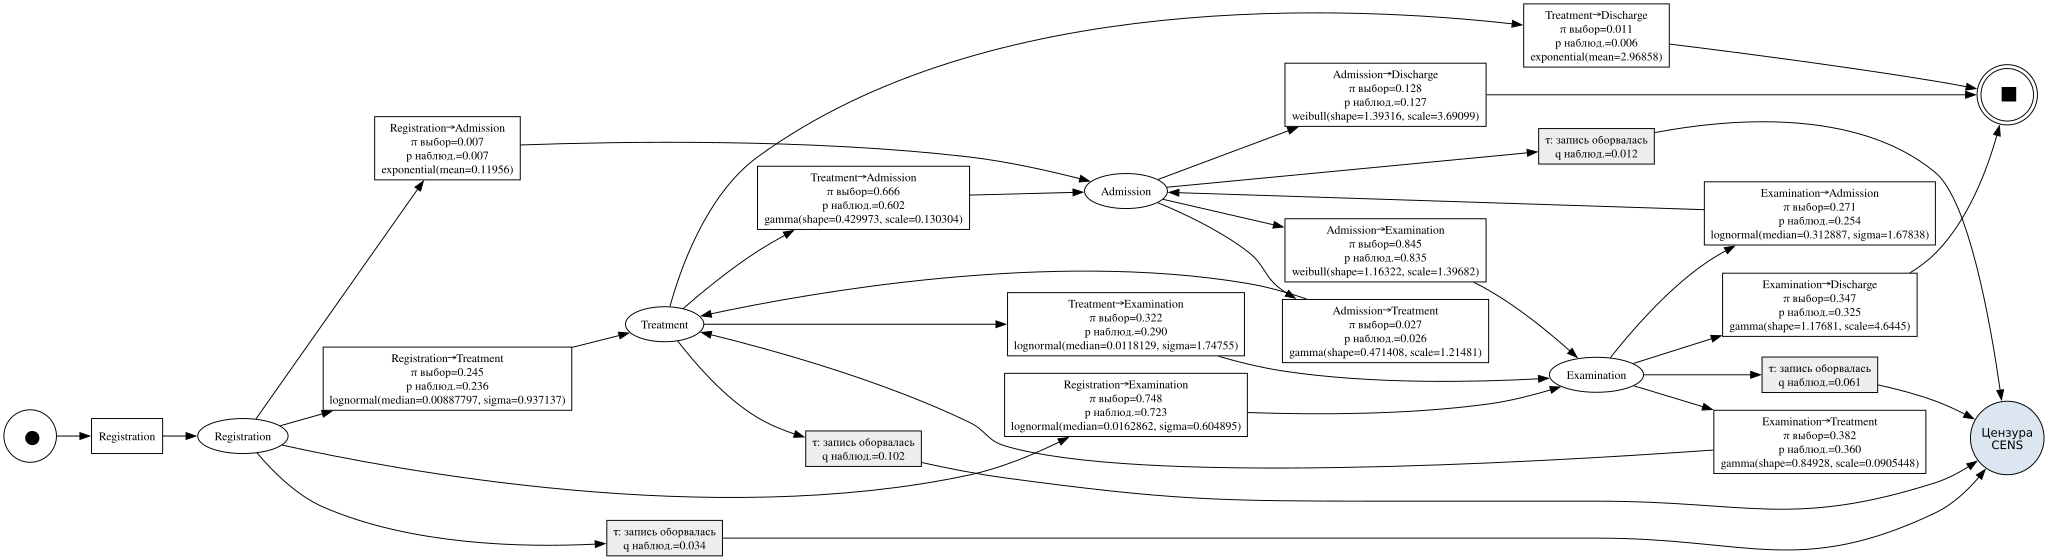

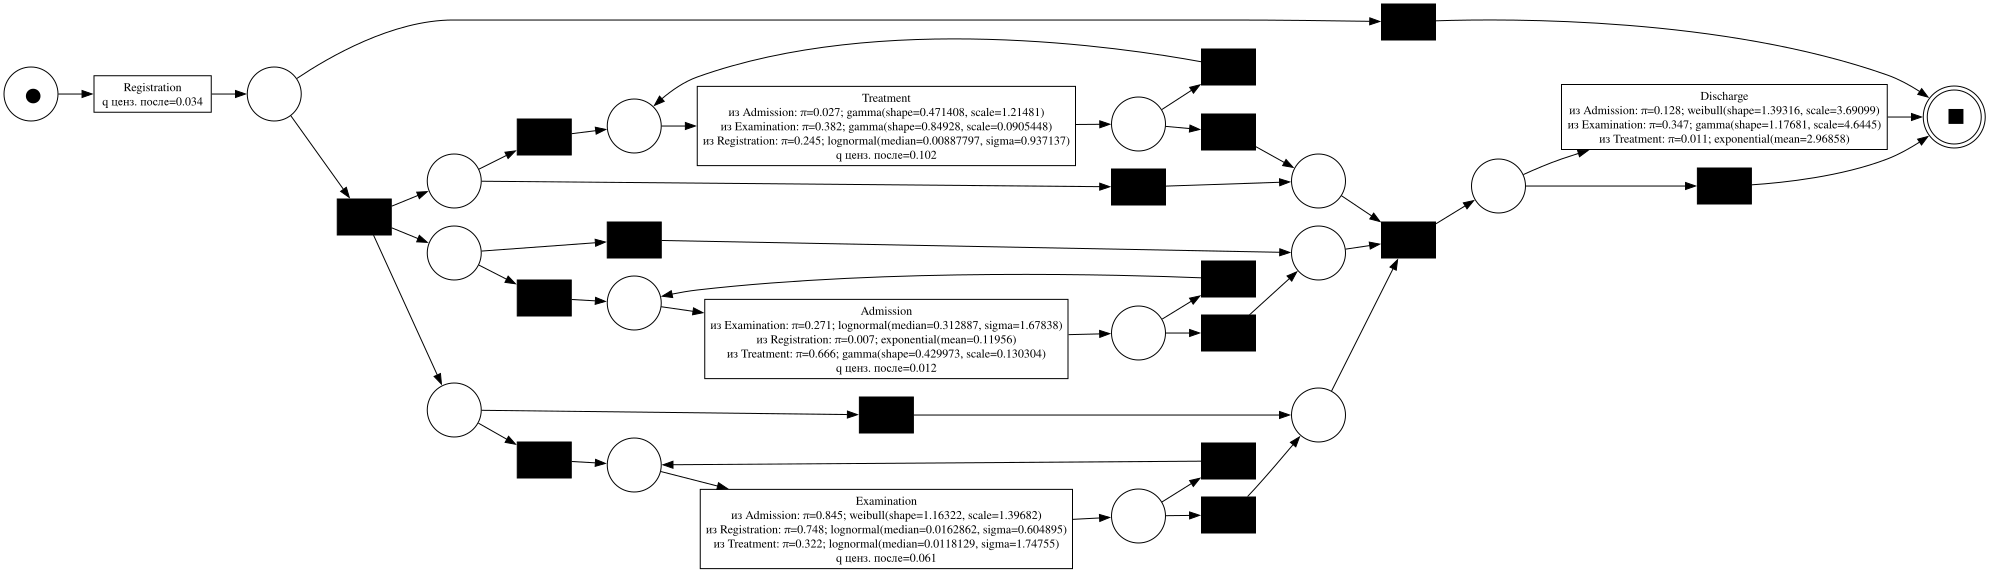

In [11]:
import pm4py
import pm4py.util.constants
from pm4py.visualization.petri_net import visualizer as pn_visualizer

pm4py.util.constants.SHOW_PROGRESS_BAR = False
frame = pm_frame(log)
event_log = pm4py.convert_to_event_log(frame)
censor_probabilities = censoring_summary(intervals)
print(f"Цензурированные трассы (запись оборвалась до {TERMINAL}): {(cases.event == 0).mean():.1%}")
display(censor_probabilities.round(4))
state_net, state_im, state_fm = state_petri_net(intervals, estimates)
im_net, im_im, im_fm = pm4py.discover_petri_net_inductive(event_log)
im_decorations = decorate_inductive(im_net, estimates, censor_probabilities)

state_decorations = {p: dict(label="Цензура\nCENS" if p.name == CENSORED else p.name,
                            color="#dce6f1" if p.name == CENSORED else "white")
                     for p in state_net.places}
for tr in state_net.transitions:
    dist = tr.properties.get("time_distribution")
    reason = tr.properties.get("censor_reason")
    if reason:
        label = "запись оборвалась" if reason == "lost" else "конец исследования"
        state_decorations[tr] = dict(label=f"τ: {label}\nq наблюд.={tr.properties['observed_probability']:.3f}",
                                     color="#eeeeee")
    elif tr.name != "start":
        choice = tr.properties["choice_probability"]
        label = f"{tr.name}\nπ выбор={choice:.3f}" if choice is not None else f"{tr.name}\nπ не оценена"
        label += f"\np наблюд.={tr.properties['observed_probability']:.3f}"
        if dist:
            label += f"\n{dist_str(dist)}"
        state_decorations[tr] = dict(label=label, color="white")
state_picture = pn_visualizer.apply(state_net, state_im, state_fm,
                                     parameters={"format": "svg", "decorations": state_decorations})
for place in state_net.places:
    if place.name == CENSORED:
        state_picture.node(str(id(place)), label="Цензура\nCENS", xlabel="", shape="circle",
                           fixedsize="false", width="1.05", height="1.05",
                           fontname="DejaVu Sans", fontsize="12")
display(state_picture)
display(pn_visualizer.apply(im_net, im_im, im_fm,
                            parameters={"format": "svg", "decorations": im_decorations}))

### 4.1 Цензурирование и фишка в CENS

Вероятности в таблице выше оцениваются по числу **ожиданий в состоянии**:

$$\widehat q_s = \frac{N_{s,\mathrm{lost}}}{N_{s,\mathrm{visits}}}.$$

Каждый вход в состояние начинает новое ожидание, поэтому одна трасса может
дать несколько наблюдений. Общая доля цензурированных **трасс** и $q_s$
имеют разные знаменатели.

На диаграмме ниже воспроизводим наблюдаемые переходы первой цензурированной
трассы, затем её остановку. Чёрная точка в голубом месте `CENS` — одна фишка
после обрыва записи. Это снимок маркировки; обычная начальная маркировка
модели по-прежнему содержит фишку в `source`.

AA: Registration → Examination → Treatment → CENS; причина=lost; наблюдение=0.22 дней


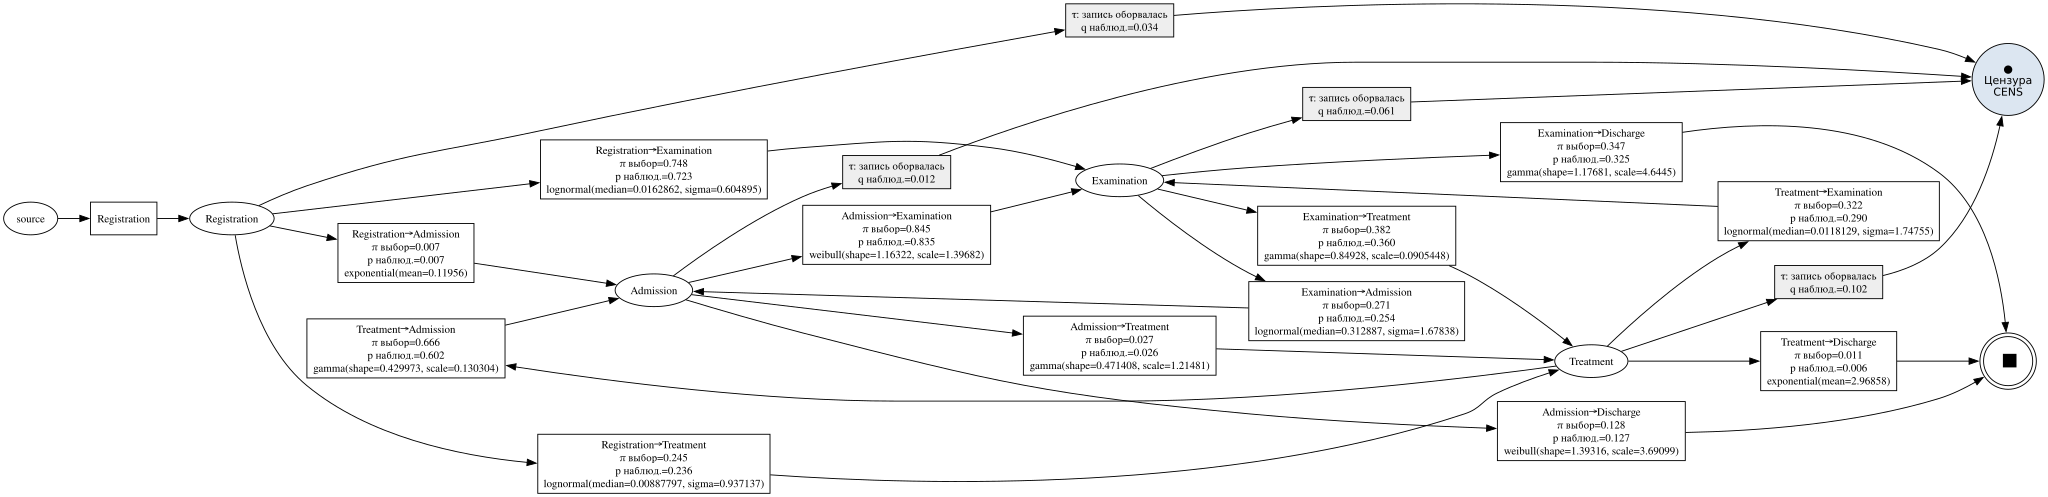

In [12]:
from pm4py.objects.petri_net.obj import Marking
from pm4py.objects.petri_net import semantics

censored_cases = cases.loc[cases.event == 0]
if len(censored_cases):
    example = censored_cases.iloc[0]
    activities = log.loc[log.case_id == example.case_id, "activity"].tolist()
    transitions_by_name = {tr.name: tr for tr in state_net.transitions}
    marking = semantics.execute(transitions_by_name["start"], state_net, state_im)
    for src, dst in zip(activities, activities[1:]):
        marking = semantics.execute(transitions_by_name[f"{src}→{dst}"], state_net, marking)
    stop = transitions_by_name[f"{example.last_state}→{CENSORED}:{example.censor_reason}"]
    marking = semantics.execute(stop, state_net, marking)
    cens_place = next(p for p in state_net.places if p.name == CENSORED)
    assert marking == Marking({cens_place: 1})
    print(f"{example.case_id}: {' → '.join(activities)} → CENS; "
          f"причина={example.censor_reason}; наблюдение={example.duration:.2f} дней")
    snapshot = pn_visualizer.apply(state_net, marking, state_fm,
                                   parameters={"format": "svg", "decorations": state_decorations})
    snapshot.node(str(id(cens_place)), label="●\nЦензура\nCENS", xlabel="", shape="circle",
                  fixedsize="false", width="1.1", height="1.1",
                  fontname="DejaVu Sans", fontsize="12")
    display(snapshot)
else:
    print("В этой выборке цензурированных трасс нет: снимок CENS не строится.")

### 4.2 Схема состояний с отдельной цензурой

Упрощённая схема показывает наблюдаемые состояния и отдельное поглощающее
состояние **«Цензура (CENS)»**. Все подписи — наблюдаемые вероятности
**за одно ожидание**: обычный выход `p наблюд.` и обрыв записи `q`.
Сумма выходов из состояния равна единице. Общая доля цензурированных трасс
приведена в подписи к рисунку.

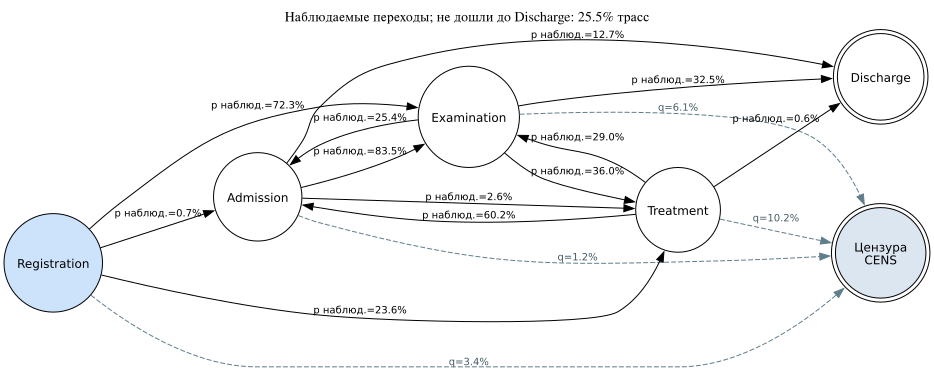

In [13]:
import graphviz

figure_dir = OUTPUT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

(figure_dir / "estimated_petri_net.png").write_bytes(state_picture.pipe(format="png"))
(figure_dir / "estimated_petri_net.svg").write_bytes(state_picture.pipe(format="svg"))
if len(censored_cases):
    (figure_dir / "censored_marking.png").write_bytes(snapshot.pipe(format="png"))
    (figure_dir / "censored_marking.svg").write_bytes(snapshot.pipe(format="svg"))

state_graph = graphviz.Digraph(graph_attr={"rankdir": "LR", "labelloc": "t", "fontsize": "14"},
                               node_attr={"fontname": "DejaVu Sans", "fontsize": "12"},
                               edge_attr={"fontname": "DejaVu Sans", "fontsize": "10"})
observed_states = sorted(set(intervals.src) | set(intervals.loc[intervals.observed, "dst"]))
for state in observed_states:
    state_graph.node(state, label=state, shape="doublecircle" if state == TERMINAL else "circle",
                     style="filled", fillcolor="#cde2fb" if state == START else "white")
state_graph.node(CENSORED, label="Цензура\nCENS", shape="doublecircle", style="filled", fillcolor="#dce6f1")
visits = censor_probabilities.set_index("src")
counts = intervals.loc[intervals.observed].groupby(["src", "dst"]).size()
for (src, dst), count in counts.items():
    probability = count / visits.loc[src, "n_visits"]
    state_graph.edge(src, dst, label=f"p наблюд.={probability:.1%}")
for src, row in visits.iterrows():
    if row.q_censored > 0:
        label = f"q={row.q_censored:.1%}"
        state_graph.edge(src, CENSORED, label=label, style="dashed", color="#607d8b", fontcolor="#455a64")
state_graph.attr(label=f"Наблюдаемые переходы; не дошли до {TERMINAL}: {(cases.event == 0).mean():.1%} трасс")
(figure_dir / "observed_states_with_censoring.svg").write_bytes(state_graph.pipe(format="svg"))
(figure_dir / "observed_states_with_censoring.png").write_bytes(state_graph.pipe(format="png"))
display(state_graph)

### 4.3 Наблюдаемые времена и восстановленные распределения

Гистограмма показывает завершённые интервалы, отобранные цензурированием.
Поэтому скорректированная плотность может не совпадать с гистограммой.
Истинной плотности у реального журнала нет: сравниваем две оценки между собой
и с данными. Ось X ограничена 98% квантилем наблюдаемых времён.

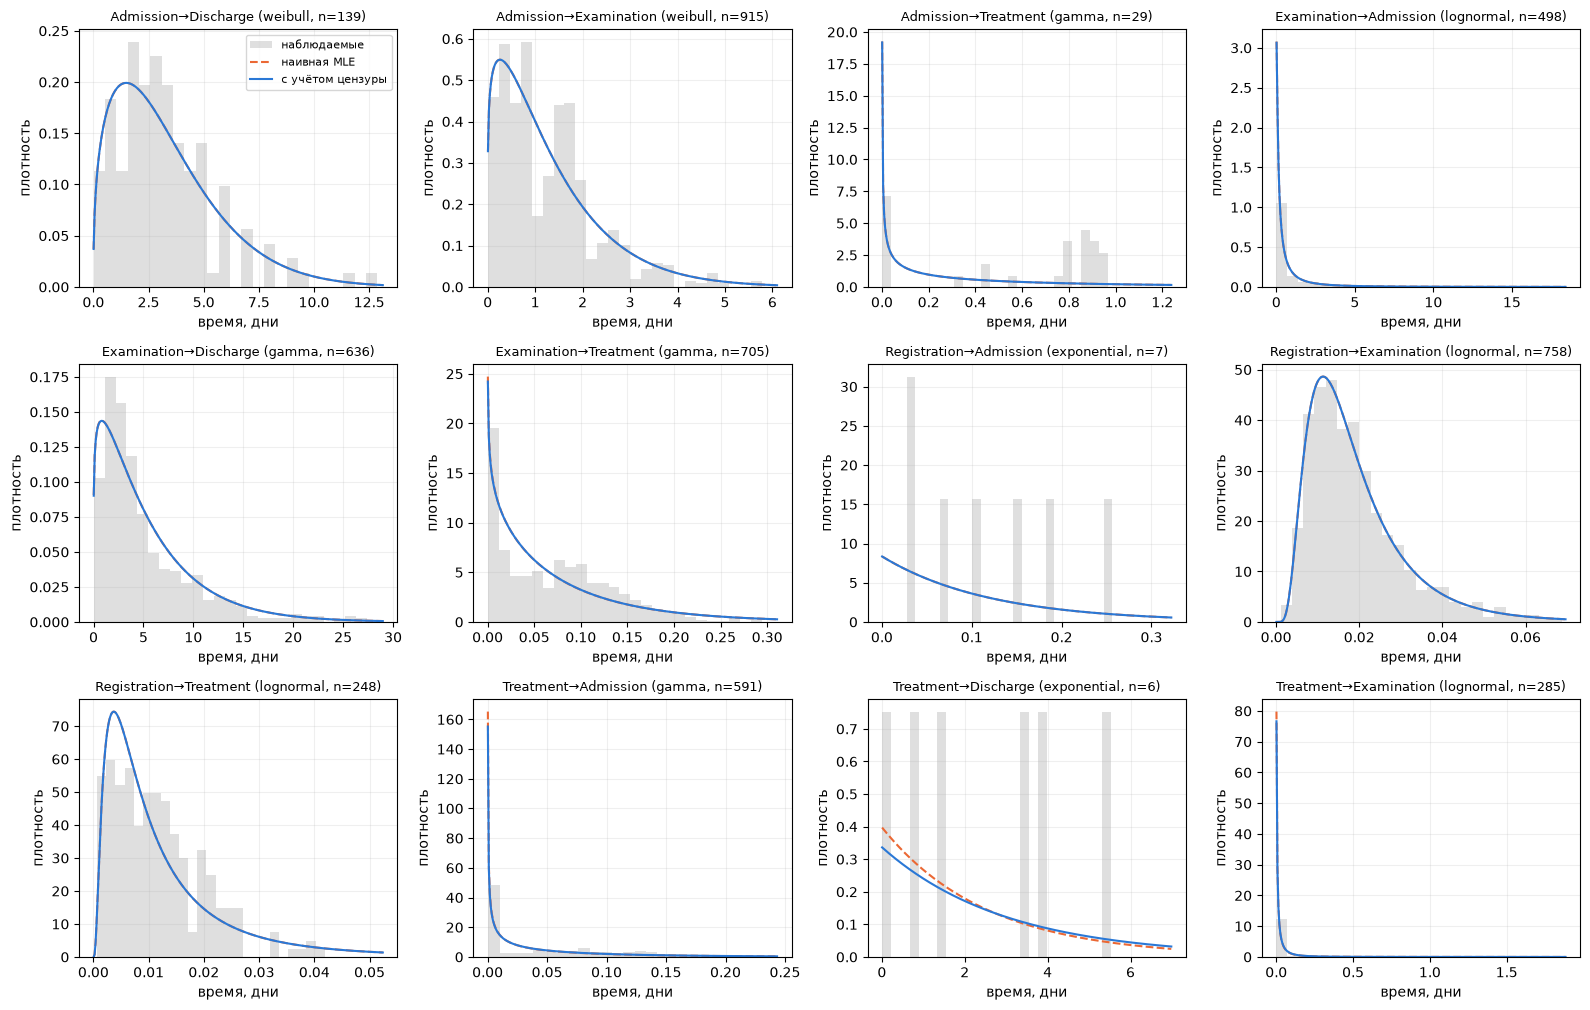

In [14]:
N_COLS = 4
n_rows = math.ceil(len(EDGES) / N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(16, 3.4 * n_rows))
for ax, edge in zip(axes.flat, EDGES):
    observed = intervals.loc[intervals.observed & (intervals.src == edge[0]) &
                             (intervals.dst == edge[1]), "duration"]
    upper = np.quantile(observed, .98)
    x = np.linspace(upper * 1e-3, upper * 1.3, 300)
    ax.hist(observed[observed <= upper * 1.3], bins=25, density=True, alpha=.25, color="gray",
            label="наблюдаемые")
    for label, dist, color, style in [
        ("наивная MLE", naive_lookup[edge]["dist"] if edge in naive_lookup else None, "#eb6834", "--"),
        ("с учётом цензуры", lookup[edge]["dist"] if edge in lookup else None, "#2a78d6", "-")]:
        if dist is not None:
            rv, args, kwargs = scipy_args(dist)
            ax.plot(x, rv.pdf(x, *args, **kwargs), color=color, ls=style, label=label)
    ax.set(title=f"{edge[0]}→{edge[1]} ({FAMILIES[edge]}, n={len(observed)})",
           xlabel="время, дни", ylabel="плотность")
    ax.title.set_fontsize(9)
    ax.grid(alpha=.2)
for ax in axes.flat[len(EDGES):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(figure_dir / "transition_density.png", dpi=160, bbox_inches="tight")
plt.show()

### 4.4 Функции распределения и выживания времён переходов

Для каждого перехода показываем функцию распределения $F_{sd}(t)=P(T_{sd}\le t)$
и функцию выживания $S_{sd}(t)=P(T_{sd}>t)=1-F_{sd}(t)$. «Выживание» здесь означает,
что выбранный переход ещё не завершился за $t$ дней.

Серая ступенчатая линия — эмпирическая функция по **завершённым** интервалам ребра
(смещена цензурированием, как наивная оценка), оранжевая — наивная оценка,
синяя — оценка с учётом цензуры. У последнего цензурированного интервала направление
неизвестно, поэтому отдельную кривую Каплана–Майера для каждого ребра не строим.

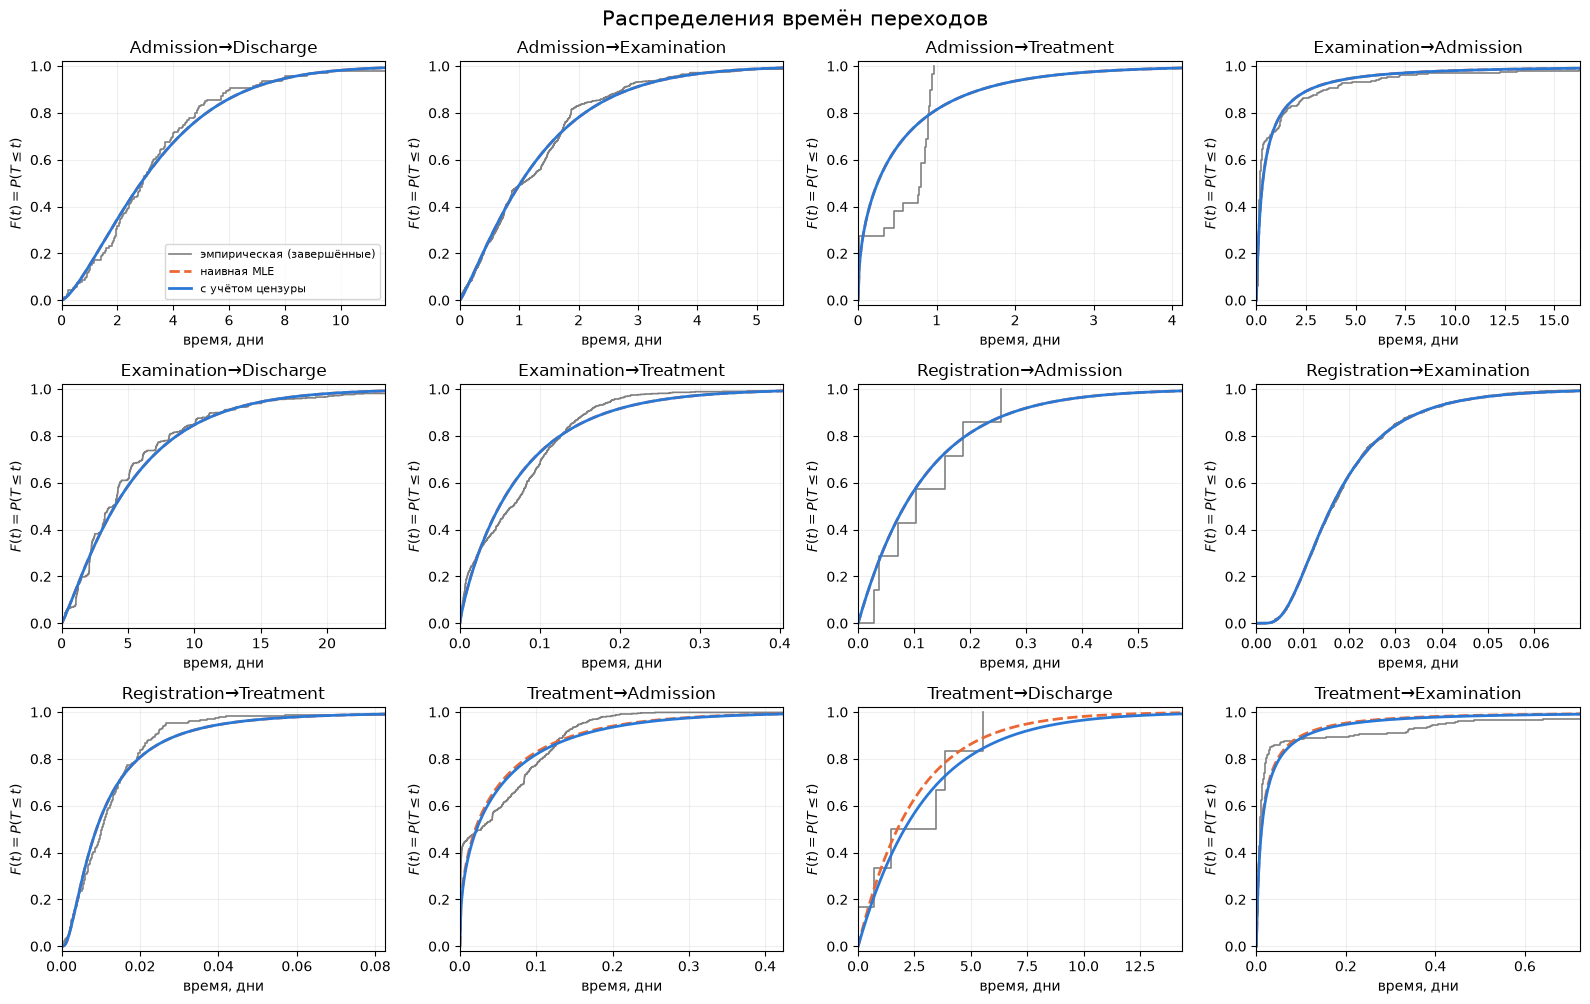

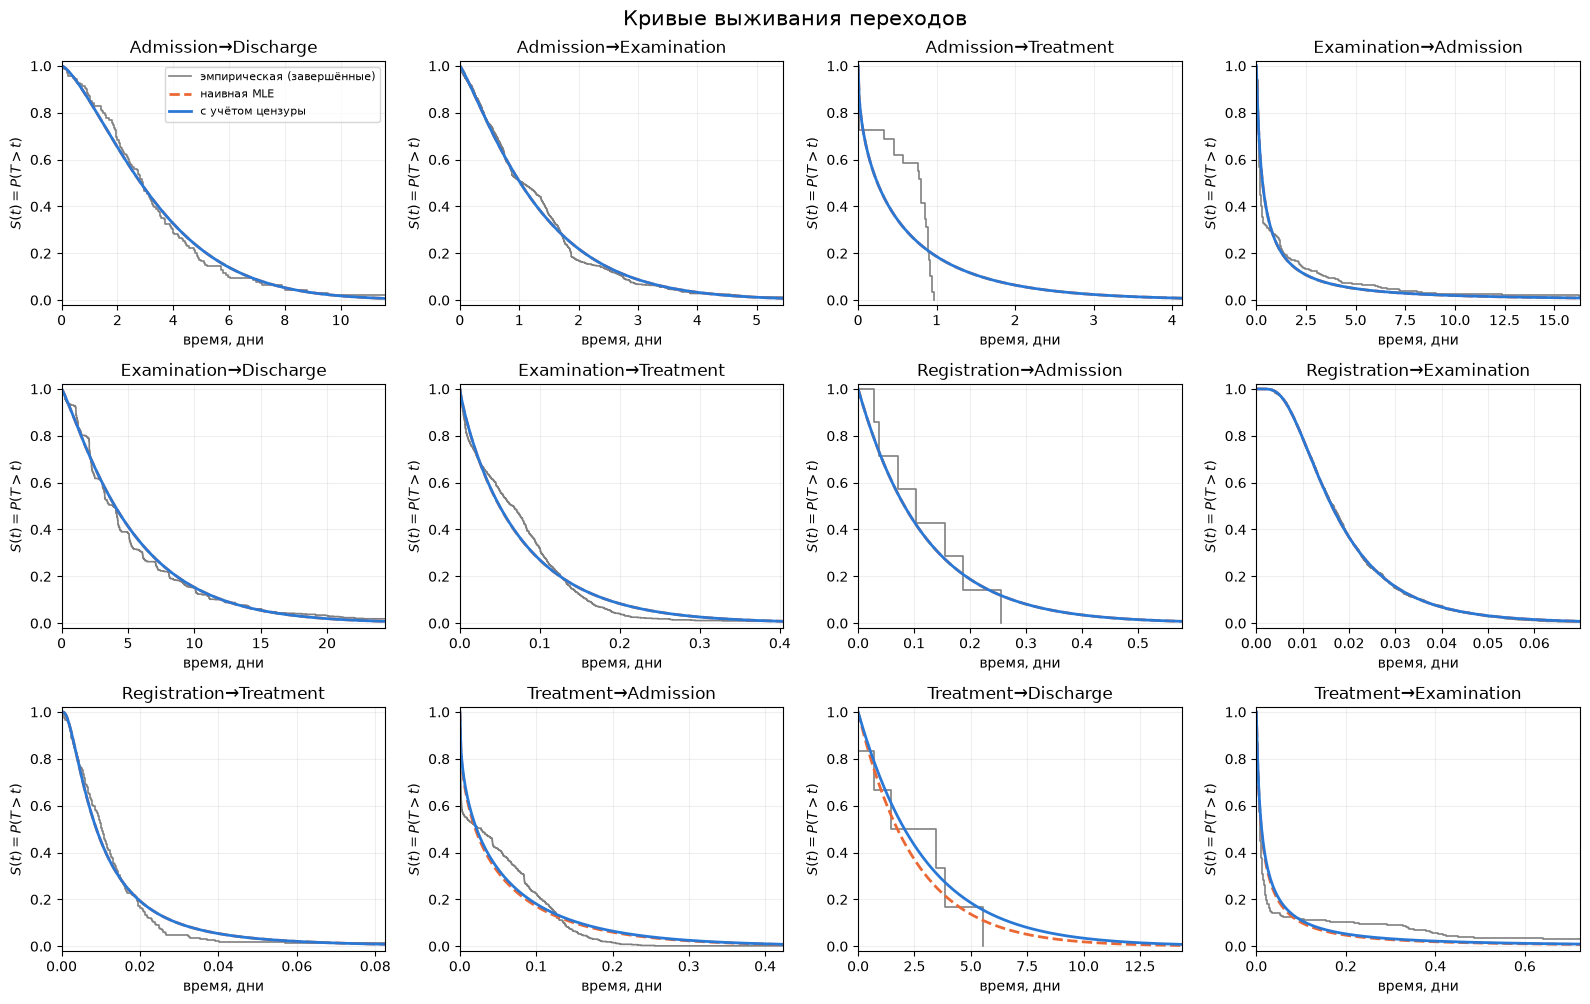

In [15]:
transition_curve_rows = []
curve_styles = [("наивная MLE", "#eb6834", "--"), ("с учётом цензуры", "#2a78d6", "-")]
for edge in EDGES:
    name = f"{edge[0]}→{edge[1]}"
    distributions = [
        ("наивная MLE", naive_lookup[edge]["dist"] if edge in naive_lookup else None),
        ("с учётом цензуры", lookup[edge]["dist"] if edge in lookup else None),
    ]
    upper = max(rv.ppf(.99, *args, **kwargs) for rv, args, kwargs in
                [scipy_args(dist) for _, dist in distributions if dist is not None])
    grid = np.linspace(0, upper * 1.05, 300)
    for label, dist in distributions:
        if dist is None:
            continue
        rv, args, kwargs = scipy_args(dist)
        cdf = rv.cdf(grid, *args, **kwargs)
        survival = rv.sf(grid, *args, **kwargs)
        assert np.allclose(cdf + survival, 1.)
        transition_curve_rows.extend(dict(transition=name, model=label, time_days=float(t),
                                          cdf=float(f), survival=float(s))
                                     for t, f, s in zip(grid, cdf, survival))
transition_curves = pd.DataFrame(transition_curve_rows)
for metric, title, ylabel in [
    ("cdf", "Распределения времён переходов", r"$F(t)=P(T\leq t)$"),
    ("survival", "Кривые выживания переходов", r"$S(t)=P(T>t)$"),
]:
    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(16, 3.4 * n_rows))
    for ax, edge in zip(axes.flat, EDGES):
        name = f"{edge[0]}→{edge[1]}"
        observed = np.sort(intervals.loc[intervals.observed & (intervals.src == edge[0]) &
                                         (intervals.dst == edge[1]), "duration"].to_numpy())
        empirical = np.arange(1, len(observed) + 1) / len(observed)
        ax.step(np.r_[0., observed], np.r_[0., empirical] if metric == "cdf" else 1 - np.r_[0., empirical],
                where="post", color="gray", lw=1.2, label="эмпирическая (завершённые)")
        for label, color, style in curve_styles:
            data = transition_curves[(transition_curves.transition == name) &
                                     (transition_curves.model == label)]
            if len(data):
                ax.plot(data.time_days, data[metric], color=color, ls=style, lw=2, label=label)
        ax.set(title=name, xlabel="время, дни", ylabel=ylabel, ylim=(-.02, 1.02),
               xlim=(0, transition_curves.loc[transition_curves.transition == name, "time_days"].max()))
        ax.grid(alpha=.2)
    for ax in axes.flat[len(EDGES):]:
        ax.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(title, fontsize=15)
    fig.tight_layout()
    fig.savefig(figure_dir / f"transition_{metric}.png", dpi=160, bbox_inches="tight")
    plt.show()

### 4.5 Общее время до выписки: плотность, распределение и выживание

Теперь $T_D$ — время от первой регистрации до первой выписки `Discharge`,
включая все повторные прохождения петель. Для обеих восстановленных моделей
генерируем по 10 000 новых трасс **без цензуры**. Вероятности направления — `π выбор`,
а не наблюдаемые частоты с учётом цензуры.

По симуляциям показываем плотность, $F_D(t)=P(T_D\le t)$ и $S_D(t)=P(T_D>t)$.
Дополнительно строим Каплана–Майера по всем трассам журнала, используя
`cases.duration` и `cases.event`. Обрыв записи остаётся цензурой.
Здесь Каплан–Майер — единственный эталон, не зависящий от выбранных семейств.

Каплан–Майер применим при независимом цензурировании. Для реального журнала это
допущение: обрыв записи может быть связан с состоянием пациента. Серая область —
время за пределами наблюдаемого диапазона. Плотности получены из гистограмм симуляций;
ось X ограничена 99% квантилем, площадь видимой части может быть меньше единицы.

In [16]:
def kaplan_meier(duration, event):
    duration, event = np.asarray(duration), np.asarray(event)
    times = np.unique(duration[event == 1])
    survival, value = [], 1.
    for t in times:
        n_risk = np.count_nonzero(duration >= t)
        n_events = np.count_nonzero((duration == t) & (event == 1))
        value *= 1 - n_events / n_risk
        survival.append(value)
    return np.r_[0., times], np.r_[1., survival]


def simulate_completion_times(transitions, n_cases, seed, max_steps=10_000):
    """Симуляция до D по переданной модели, без цензуры, с повторными посещениями."""
    rng = np.random.default_rng(seed)
    outgoing = {}
    for transition in transitions:
        outgoing.setdefault(transition["src"], []).append(transition)
    times = np.empty(n_cases)
    for i in range(n_cases):
        state, elapsed = START, 0.
        for _ in range(max_steps):
            candidates = outgoing[state]
            transition = candidates[rng.choice(len(candidates), p=[t["p"] for t in candidates])]
            elapsed += sample_time(transition["dist"], rng)
            state = transition["dst"]
            if state == TERMINAL:
                times[i] = elapsed
                break
        else:
            raise RuntimeError("Превышено max_steps при симуляции восстановленной модели")
    return times

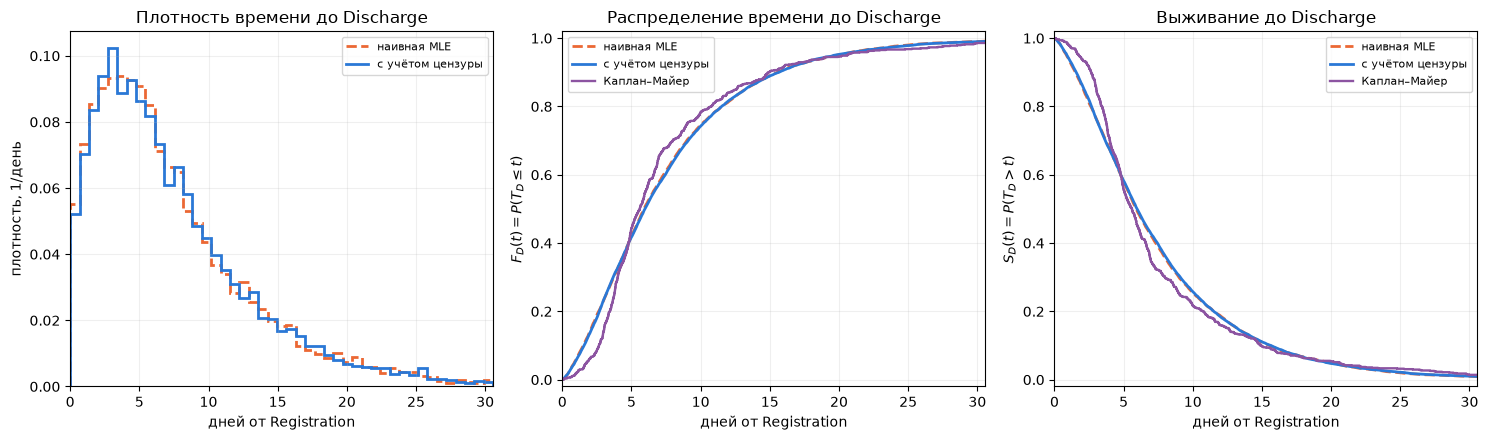

,count,mean,median
model,,,
наивная MLE,10000,7.592,5.901
с учётом цензуры,10000,7.628,5.970


In [17]:
def complete_model(transitions):
    sources = {t["src"] for t in transitions}
    return ({START} | {t["dst"] for t in transitions}) - {TERMINAL} <= sources


COMPLETION_CASES = 10_000
completion_samples = {}
model_specs = [("наивная MLE", naive_estimates), ("с учётом цензуры", estimates)]
for index, (label, transitions) in enumerate(model_specs):
    if not complete_model(transitions):
        print(f"{label}: модель неполна, общую кривую до {TERMINAL} не строим")
        continue
    completion_samples[label] = simulate_completion_times(transitions, COMPLETION_CASES, seed=87103 + index)

km_times, km_survival = kaplan_meier(cases.duration, cases.event)
observed_end = float(cases.duration.max())
plot_end = max([np.quantile(cases.duration, .99)] +
               [np.quantile(times, .99) for times in completion_samples.values()])
grid = np.linspace(0, plot_end, 400)
bins = np.linspace(0, plot_end, 46)
km_plot_times = np.r_[km_times, observed_end]
km_plot_survival = np.r_[km_survival, km_survival[-1]]
completion_curve_rows = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for label, color, style in curve_styles:
    if label not in completion_samples:
        continue
    times = completion_samples[label]
    counts, _ = np.histogram(times, bins=bins)
    density = counts / (len(times) * np.diff(bins))
    cdf = np.searchsorted(np.sort(times), grid, side="right") / len(times)
    survival = 1 - cdf
    axes[0].stairs(density, bins, color=color, linestyle=style, linewidth=2, label=label)
    axes[1].plot(grid, cdf, color=color, ls=style, lw=2, label=label)
    axes[2].plot(grid, survival, color=color, ls=style, lw=2, label=label)
    completion_curve_rows.extend(dict(model=label, time_days=float(t), cdf=float(f), survival=float(s))
                                 for t, f, s in zip(grid, cdf, survival))
axes[1].step(km_plot_times, 1 - km_plot_survival, where="post", color="#8c54a1", lw=1.7, label="Каплан–Майер")
axes[2].step(km_plot_times, km_plot_survival, where="post", color="#8c54a1", lw=1.7, label="Каплан–Майер")
for ax, title, ylabel in zip(axes, [f"Плотность времени до {TERMINAL}", f"Распределение времени до {TERMINAL}",
                                    f"Выживание до {TERMINAL}"],
                             ["плотность, 1/день", r"$F_D(t)=P(T_D\leq t)$", r"$S_D(t)=P(T_D>t)$"]):
    ax.set(title=title, xlabel=f"дней от {START}", ylabel=ylabel, xlim=(0, plot_end))
    if observed_end < plot_end:
        ax.axvspan(observed_end, plot_end, color="gray", alpha=.1)
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
axes[1].set_ylim(-.02, 1.02)
axes[2].set_ylim(-.02, 1.02)
fig.tight_layout()
fig.savefig(figure_dir / "completion_curves.png", dpi=160, bbox_inches="tight")
plt.show()

completion_curves = pd.DataFrame(completion_curve_rows)
completion_times = pd.concat([pd.DataFrame(dict(model=label, duration_days=times))
                              for label, times in completion_samples.items()], ignore_index=True)
display(completion_times.groupby("model").duration_days.agg(["count", "mean", "median"]).round(3))

## 5. Качество при разном числе трасс

Истинных параметров нет, поэтому вместо генерации новых журналов делим реальный журнал:

* **тест** — случайные 30% трасс; никогда не участвуют в обучении;
* **train** — остальные 70%; из них для каждого повтора берём случайную перестановку
  и первые $N$ трасс, поэтому выборки вложены друг в друга. Последний размер — весь train
  (при нём все повторы совпадают).

**Эталон** для каждого метода — его же оценка на всём train. Метрики `parameter_mape`,
`mean_time_mape`, `probability_mae`, `cdf_error` (формулы как в синтетическом ноутбуке)
показывают, насколько оценка на $N$ трассах отклоняется от оценки на полном train,
то есть **устойчивость и сходимость, а не точность**. Смещение наивной оценки этими
метриками не видно: она сходится к своему (смещённому) пределу.

Сравнить методы между собой позволяет `test_nll` — среднее $-\log L$ на интервал
отложенных трасс, посчитанное по полному правдоподобию **с цензурой** для обеих моделей
(меньше — лучше). Интервалы теста, ребро или источник которых модель не оценила,
пропускаются; их доля — `test_coverage`.

Остальные метрики: `edge_recall`, `parameter_coverage` — доля рёбер эталона,
обнаруженных и оценённых на $N$ трассах; `fitness_*`, `precision_complete` —
token-based метрики Inductive Miner на тесте (полные трассы заканчиваются в `Discharge`);
`fit_success_fraction` — доля источников с успешной оптимизацией.
Семейства `FAMILIES` фиксированы (выбраны в разделе 3.1 по всему журналу).

In [18]:
TRACE_COUNTS = [10, 30, 50, 100, 300, 500]
N_REPEATS = 5
TEST_FRACTION = .3
EXPERIMENT_SEED = 2026
METHODS = [("naive", False), ("censor_aware", True)]

case_ids = cases.case_id.to_numpy()
test_ids = set(np.random.default_rng(SEED).choice(case_ids, size=round(TEST_FRACTION * len(case_ids)),
                                                  replace=False))
train_ids = np.array([c for c in case_ids if c not in test_ids])
TRACE_COUNTS = [n for n in TRACE_COUNTS if n < len(train_ids)] + [len(train_ids)]
train_intervals = intervals[intervals.case_id.isin(train_ids)]
test_intervals = intervals[intervals.case_id.isin(test_ids)]
REFERENCES = {method: {(t["src"], t["dst"]): t
                       for t in estimate_network(train_intervals, FAMILIES, corrected)[0]}
              for method, corrected in METHODS}
print(f"train: {len(train_ids)} трасс; тест: {len(test_ids)} трасс; размеры N: {TRACE_COUNTS}")
print({method: len(reference) for method, reference in REFERENCES.items()}, "рёбер в эталонах")

train: 734 трасс; тест: 315 трасс; размеры N: [10, 30, 50, 100, 300, 500, 734]
{'naive': 12, 'censor_aware': 12} рёбер в эталонах


In [19]:
def reconstruction_metrics(intervals, estimates, reference):
    true_edges = set(reference)
    found = set(intervals.loc[intervals.observed, ["src", "dst"]].itertuples(index=False, name=None))
    fitted = {(t["src"], t["dst"]): t for t in estimates}
    metrics = dict(edge_recall=len(found & true_edges) / len(true_edges),
                   parameter_coverage=len(set(fitted) & true_edges) / len(true_edges),
                   parameter_mape=np.nan, mean_time_mape=np.nan, probability_mae=np.nan,
                   cdf_error=np.nan)
    if not true_edges.issubset(fitted):
        return metrics
    parameter_errors, mean_errors, probability_errors, cdf_errors = [], [], [], []
    for edge, target in reference.items():
        estimated = fitted[edge]
        parameter_errors.extend(abs(estimated["dist"][1][name] / value - 1)
                                for name, value in target["dist"][1].items())
        mean_errors.append(abs(mean_time(estimated["dist"]) / mean_time(target["dist"]) - 1))
        probability_errors.append(abs(estimated["p"] - target["p"]))
        rv_true, args_true, kwargs_true = scipy_args(target["dist"])
        rv_est, args_est, kwargs_est = scipy_args(estimated["dist"])
        quantiles = np.linspace(.01, .99, 99)
        grid = rv_true.ppf(quantiles, *args_true, **kwargs_true)
        cdf_errors.append(np.abs(rv_est.cdf(grid, *args_est, **kwargs_est) - quantiles).mean())
    metrics.update(parameter_mape=np.mean(parameter_errors), mean_time_mape=np.mean(mean_errors),
                   probability_mae=np.mean(probability_errors), cdf_error=np.mean(cdf_errors))
    return metrics


def miner_metrics(training_log, test_log, complete_test_log):
    import pm4py
    started = perf_counter()
    net, im, fm = pm4py.discover_petri_net_inductive(training_log)
    discovery_seconds = perf_counter() - started
    started = perf_counter()
    metrics = dict(
        fitness_all=pm4py.fitness_token_based_replay(test_log, net, im, fm)["average_trace_fitness"],
        fitness_complete=pm4py.fitness_token_based_replay(complete_test_log, net, im, fm)["average_trace_fitness"],
        precision_complete=pm4py.precision_token_based_replay(complete_test_log, net, im, fm),
        n_places=len(net.places), n_transitions=len(net.transitions),
        n_silent=sum(t.label is None for t in net.transitions),
    )
    metrics["conformance_seconds"] = perf_counter() - started
    metrics["discovery_seconds"] = discovery_seconds
    return metrics



def heldout_nll(test_intervals, estimates):
    """Среднее −log L на интервал теста с цензурой; интервалы вне модели пропускаются."""
    fitted = {(t["src"], t["dst"]): t for t in estimates}
    total, n_used = 0., 0
    for src, group in test_intervals.groupby("src"):
        edges = [edge for edge in fitted if edge[0] == src]
        if not edges:
            continue
        group = group[~group.observed | group.dst.isin([edge[1] for edge in edges])]
        total += source_nll(group, edges, [fitted[e]["p"] for e in edges], [fitted[e]["dist"] for e in edges])
        n_used += len(group)
    return dict(test_nll=total / n_used if n_used else np.nan, test_coverage=n_used / len(test_intervals))

In [20]:
experiment_started = perf_counter()
test_log, test_cases = log[log.case_id.isin(test_ids)], cases[cases.case_id.isin(test_ids)]
test_event_log = pm4py.convert_to_event_log(pm_frame(test_log))
complete_ids = set(test_cases.loc[test_cases.event == 1, "case_id"])
complete_test_event_log = pm4py.convert_to_event_log(pm_frame(test_log[test_log.case_id.isin(complete_ids)]))
assert len(complete_test_event_log) > 0
print(f"Отложенный тест: {len(test_event_log)} трасс, {len(complete_test_event_log)} полных")

result_rows, parameter_rows, diagnostic_rows, miner_rows, timing_rows = [], [], [], [], []
for repeat in range(N_REPEATS):
    order = np.random.default_rng(EXPERIMENT_SEED + repeat).permutation(train_ids)
    for n in TRACE_COUNTS:
        run_started = perf_counter()
        subset_ids = set(order[:n])
        subset_log, subset_cases = log[log.case_id.isin(subset_ids)], cases[cases.case_id.isin(subset_ids)]
        timing = dict(n_traces=n, repeat=repeat, n_events=len(subset_log))
        started = perf_counter()
        subset_intervals = make_intervals(subset_log, subset_cases)
        timing["interval_preparation_seconds"] = perf_counter() - started
        started = perf_counter()
        training_event_log = pm4py.convert_to_event_log(pm_frame(subset_log))
        timing["pm_preparation_seconds"] = perf_counter() - started
        discovered = miner_metrics(training_event_log, test_event_log, complete_test_event_log)
        timing["discovery_seconds"] = discovered["discovery_seconds"]
        timing["conformance_seconds"] = discovered["conformance_seconds"]
        miner_rows.append(dict(n_traces=n, repeat=repeat, **discovered))
        for method, corrected in METHODS:
            started = perf_counter()
            fitted, fit_diagnostics = estimate_network(subset_intervals, FAMILIES, corrected)
            fit_seconds = perf_counter() - started
            timing[f"{method}_fit_seconds"] = fit_seconds
            metrics = reconstruction_metrics(subset_intervals, fitted, REFERENCES[method])
            metrics.update(heldout_nll(test_intervals, fitted))
            result_rows.append(dict(n_traces=n, repeat=repeat, method=method, fit_seconds=fit_seconds,
                                    censored_fraction=1 - subset_cases.event.mean(),
                                    fit_success_fraction=fit_diagnostics.success.mean(), **metrics))
            table = parameter_table(fitted, REFERENCES[method], subset_intervals)
            table["n_traces"], table["repeat"], table["method"] = n, repeat, method
            parameter_rows.extend(table.to_dict("records"))
            diagnostic_rows.extend(fit_diagnostics.assign(n_traces=n, repeat=repeat,
                                                          method=method).to_dict("records"))
        timing["total_seconds"] = perf_counter() - run_started
        timing_rows.append(timing)
    print(f"Повтор {repeat + 1}/{N_REPEATS} завершён", flush=True)

experiment_seconds = perf_counter() - experiment_started
timings = pd.DataFrame(timing_rows)
results = pd.DataFrame(result_rows)
parameter_results = pd.DataFrame(parameter_rows)
fit_diagnostics = pd.DataFrame(diagnostic_rows)
miner_results = pd.DataFrame(miner_rows)
metrics = ["edge_recall", "parameter_coverage", "parameter_mape", "mean_time_mape",
           "probability_mae", "cdf_error", "test_nll", "test_coverage", "fit_success_fraction"]
summary = results.groupby(["n_traces", "method"])[metrics].agg(["mean", "std", "count"])
display(summary.round(4))
display(miner_results.groupby("n_traces").mean(numeric_only=True).drop(columns="repeat").round(4))
print("Источников без полной оценки:", int((~fit_diagnostics.success).sum()))
display(fit_diagnostics.loc[~fit_diagnostics.success])

Отложенный тест: 315 трасс, 240 полных


Повтор 1/5 завершён


Повтор 2/5 завершён


Повтор 3/5 завершён


Повтор 4/5 завершён


Повтор 5/5 завершён


edge_recall               parameter_coverage          \
                             mean     std count               mean     std   
n_traces method                                                              
10       censor_aware      0.7500  0.0000     5             0.3833  0.1826   
         naive             0.7500  0.0000     5             0.3833  0.1826   
30       censor_aware      0.7500  0.0000     5             0.7167  0.0745   
         naive             0.7500  0.0000     5             0.7167  0.0745   
50       censor_aware      0.7833  0.0456     5             0.6833  0.0913   
         naive             0.7833  0.0456     5             0.6833  0.0913   
100      censor_aware      0.8500  0.0373     5             0.6000  0.0373   
         naive             0.8500  0.0373     5             0.6000  0.0373   
300      censor_aware      0.9167  0.0833     5             0.9167  0.0833   
         naive             0.9167  0.0833     5             0.9167  0.0833   
500      censor_aware      0.9833  0.0373     5             0.9833  0.0373   
         naive             0.9833  0.0373     5             0.9833  0.0373   
734      censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   

                            parameter_mape               mean_time_mape  ...  \
                      count           mean     std count           mean  ...   
n_traces method                                                          ...   
10       censor_aware     5            NaN     NaN     0            NaN  ...   
         naive            5            NaN     NaN     0            NaN  ...   
30       censor_aware     5            NaN     NaN     0            NaN  ...   
         naive            5            NaN     NaN     0            NaN  ...   
50       censor_aware     5            NaN     NaN     0            NaN  ...   
         naive            5            NaN     NaN     0            NaN  ...   
100      censor_aware     5            NaN     NaN     0            NaN  ...   
         naive            5            NaN     NaN     0            NaN  ...   
300      censor_aware     5         0.1082  0.0340     2         0.1760  ...   
         naive            5         0.1052  0.0320     2         0.1668  ...   
500      censor_aware     5         0.0587  0.0171     4         0.0949  ...   
         naive            5         0.0579  0.0185     4         0.0920  ...   
734      censor_aware     5         0.0000  0.0000     5         0.0000  ...   
         naive            5         0.0000  0.0000     5         0.0000  ...   

                      cdf_error test_nll               test_coverage          \
                          count     mean     std count          mean     std   
n_traces method                                                                
10       censor_aware         0   1.0631  1.0982     5        0.5398  0.2203   
         naive                0   1.0615  1.1008     5        0.5398  0.2203   
30       censor_aware         0   0.0870  0.2101     5        0.9464  0.0924   
         naive                0   0.0851  0.2088     5        0.9464  0.0924   
50       censor_aware         0   0.0079  0.3174     5        0.9051  0.1132   
         naive                0   0.0059  0.3182     5        0.9051  0.1132   
100      censor_aware         0  -0.3581  0.0165     5        0.7816  0.0012   
         naive                0  -0.3595  0.0173     5        0.7816  0.0012   
300      censor_aware         2   0.1129  0.0191     5        0.9970  0.0029   
         naive                2   0.1130  0.0187     5        0.9970  0.0029   
500      censor_aware         4   0.1221  0.0086     5        0.9995  0.0012   
         naive                4   0.1219  0.0089     5        0.9995  0.0012   
734      censor_aware         5   0.1241  0.0000     5        1.0000  0.0000   
         naive                5   0.1241  0.0000     5

,fitness_all,fitness_complete,precision_complete,n_places,n_transitions,n_silent,conformance_seconds,discovery_seconds
n_traces,,,,,,,,
10,0.9666,0.9902,0.7038,11.8,15.8,10.8,0.0183,0.0011
30,0.9910,0.9945,0.6835,13.2,18.4,13.4,0.0212,0.0013
50,0.9985,0.9980,0.6730,13.2,18.4,13.4,0.0208,0.0013
100,0.9988,0.9985,0.6730,12.0,16.2,11.2,0.0192,0.0014
300,0.9997,0.9996,0.6374,15.6,20.4,15.4,0.0269,0.0019
500,1.0000,1.0000,0.6383,16.0,21.0,16.0,0.0283,0.0023
734,1.0000,1.0000,0.6383,16.0,21.0,16.0,0.0262,0.0022


Источников без полной оценки: 38


,src,success,status,n_completed,n_censored,nll,message,at_boundary,n_traces,repeat,method
0,Admission,False,insufficient_data,12,0,NaN,NaN,NaN,10,0,naive
2,Registration,False,insufficient_data,9,1,NaN,NaN,NaN,10,0,naive
3,Treatment,False,insufficient_data,7,0,NaN,NaN,NaN,10,0,naive
4,Admission,False,insufficient_data,12,0,NaN,NaN,NaN,10,0,censor_aware
6,Registration,False,insufficient_data,9,1,NaN,NaN,NaN,10,0,censor_aware
7,Treatment,False,insufficient_data,7,0,NaN,NaN,NaN,10,0,censor_aware
24,Admission,False,insufficient_data,104,2,NaN,NaN,NaN,100,0,naive
28,Admission,False,insufficient_data,104,2,NaN,NaN,NaN,100,0,censor_aware
56,Admission,False,insufficient_data,10,0,NaN,NaN,NaN,10,1,naive
60,Admission,False,insufficient_data,10,0,NaN,NaN,NaN,10,1,censor_aware


### 5.1 Кривые качества

Линии — среднее по повторам, полоса — диапазон 10–90% результатов повторов
(**не доверительный интервал**). На оси X число трасс в логарифмическом масштабе.
Пропуски временных ошибок означают неполное восстановление параметров.
Ошибки — отклонение от оценки того же метода на всём train, не от истины.
Число успешно оценённых повторов видно в таблице `summary` (`count`).

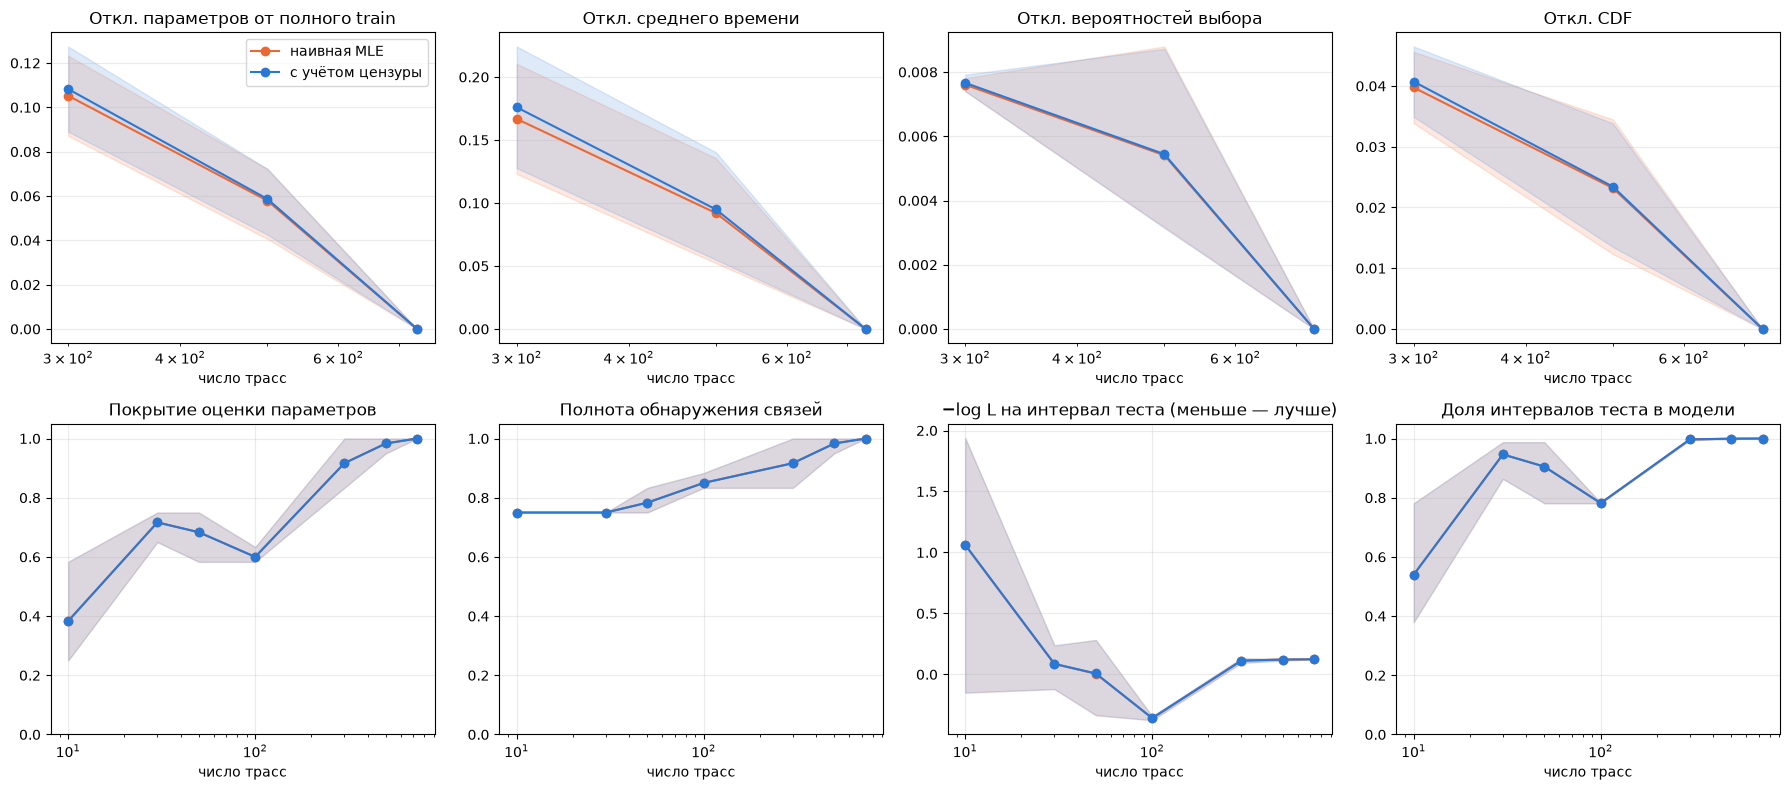

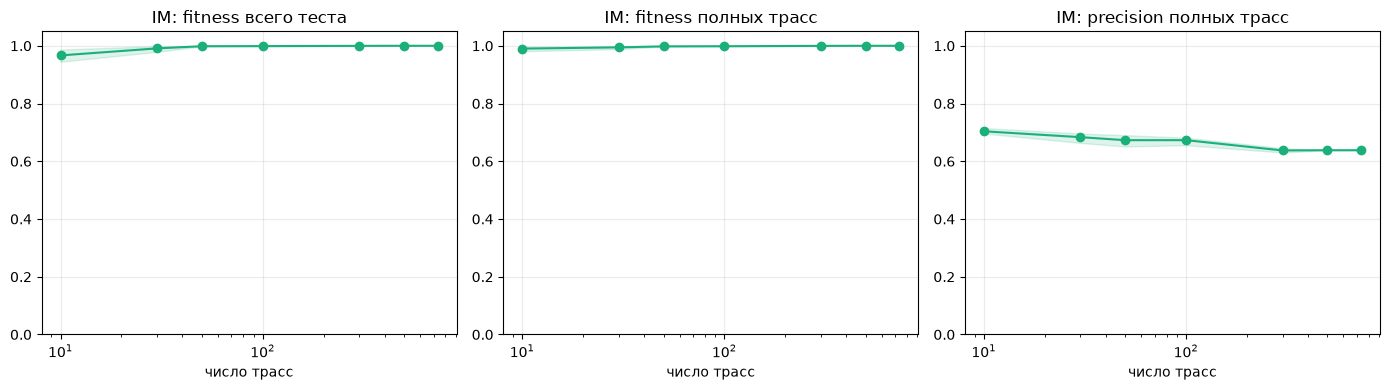

In [21]:
def plot_band(ax, table, metric, label, color):
    grouped = table.groupby("n_traces")[metric]
    x = np.array(sorted(table.n_traces.unique()))
    average = grouped.mean().reindex(x)
    lo, hi = grouped.quantile(.1).reindex(x), grouped.quantile(.9).reindex(x)
    ax.plot(x, average, "o-", label=label, color=color)
    ax.fill_between(x, lo, hi, alpha=.15, color=color)
    ax.set_xscale("log")
    ax.set_xlabel("число трасс")
    ax.grid(alpha=.25)


fig, axes = plt.subplots(2, 4, figsize=(18, 8))
titles = dict(parameter_mape="Откл. параметров от полного train", mean_time_mape="Откл. среднего времени",
              probability_mae="Откл. вероятностей выбора", cdf_error="Откл. CDF",
              parameter_coverage="Покрытие оценки параметров", edge_recall="Полнота обнаружения связей",
              test_nll="−log L на интервал теста (меньше — лучше)", test_coverage="Доля интервалов теста в модели")
for ax, (metric, title) in zip(axes.flat, titles.items()):
    for method, label, color in [("naive", "наивная MLE", "#eb6834"),
                                ("censor_aware", "с учётом цензуры", "#2a78d6")]:
        plot_band(ax, results[results.method == method], metric, label, color)
    ax.set_title(title)
    if metric in ("edge_recall", "parameter_coverage", "test_coverage"):
        ax.set_ylim(0, 1.05)
axes.flat[0].legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(axes, ["fitness_all", "fitness_complete", "precision_complete"],
                             ["IM: fitness всего теста", "IM: fitness полных трасс", "IM: precision полных трасс"]):
    plot_band(ax, miner_results, metric, "Inductive Miner", "#1baf7a")
    ax.set(title=title, ylim=(0, 1.05))
fig.tight_layout()
plt.show()

### 5.2 Ошибки отдельных переходов и параметров

Общая средняя ошибка может скрывать плохо восстановленное редкое ребро.
Тепловая карта показывает относительную ошибку каждого параметра отдельно
для модели с учётом цензуры относительно её оценки на всём train. Таблица содержит число доступных оценок по повторам.

mean  count
label                        n_traces               
Admission→Discharge: scale   10           NaN      0
                             30        0.1734      4
                             50        0.0991      3
                             100          NaN      0
                             300       0.0653      5
...                                       ...    ...
Treatment→Examination: sigma 50        0.2447      5
                             100       0.0840      5
                             300       0.0823      5
                             500       0.0273      5
                             734       0.0000      5

[154 rows x 2 columns]

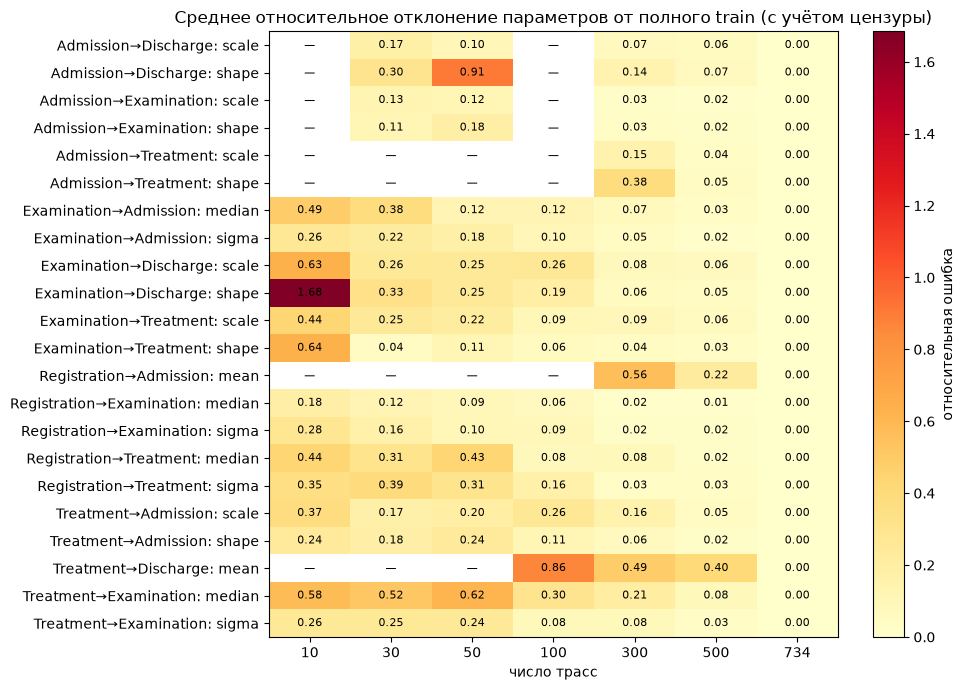

In [22]:
corrected = parameter_results[parameter_results.method == "censor_aware"].copy()
corrected["label"] = corrected["transition"] + ": " + corrected["parameter"]
per_parameter = corrected.groupby(["label", "n_traces"])["relative_error"].agg(["mean", "count"])
display(per_parameter.round(4))
heatmap = corrected.pivot_table(index="label", columns="n_traces", values="relative_error", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 7))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0)
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns)
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set(xlabel="число трасс", title="Среднее относительное отклонение параметров от полного train (с учётом цензуры)")
for i in range(len(heatmap)):
    for j in range(len(heatmap.columns)):
        value = heatmap.iloc[i, j]
        ax.text(j, i, f"{value:.2f}" if np.isfinite(value) else "—", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="относительная ошибка")
fig.tight_layout()
plt.show()

### 5.3 Время выполнения

Измеряем прошедшее время в секундах через `time.perf_counter()`:

* `interval_preparation_seconds` — построение завершённых и цензурированных интервалов;
* `pm_preparation_seconds` — преобразование обучающего журнала в формат PM4Py;
* `discovery_seconds` — восстановление структуры Inductive Miner;
* `conformance_seconds` — расчёт fitness и precision на фиксированном тестовом логе;
* `naive_fit_seconds`, `censor_aware_fit_seconds` — оценка вероятностей и параметров;
* `total_seconds` — весь расчёт одного размера $N$ в одном повторе, включая оба
  оценивателя, проверку качества и сбор результатов. Построение графиков сюда не входит.

Тестовый журнал всегда одинаковый, поэтому время проверки соответствия не является
временем обработки $N$ трасс. Результаты зависят от компьютера и его текущей нагрузки.

Время экспериментальной ячейки: 23.08 с


interval_preparation_seconds               pm_preparation_seconds  \
                                 mean     std count                   mean   
n_traces                                                                     
10                             0.0017  0.0003     5                 0.0036   
30                             0.0016  0.0006     5                 0.0037   
50                             0.0016  0.0002     5                 0.0040   
100                            0.0015  0.0002     5                 0.0052   
300                            0.0018  0.0002     5                 0.0109   
500                            0.0021  0.0007     5                 0.0267   
734                            0.0020  0.0003     5                 0.0286   

                       discovery_seconds               conformance_seconds  \
             std count              mean     std count                mean   
n_traces                                                                     
10        0.0005     5            0.0011  0.0003     5              0.0183   
30        0.0008     5            0.0013  0.0004     5              0.0212   
50        0.0003     5            0.0013  0.0001     5              0.0208   
100       0.0003     5            0.0014  0.0001     5              0.0192   
300       0.0007     5            0.0019  0.0001     5              0.0269   
500       0.0226     5            0.0023  0.0007     5              0.0283   
734       0.0183     5            0.0022  0.0001     5              0.0262   

          ...       naive_fit_seconds               censor_aware_fit_seconds  \
          ... count              mean     std count                     mean   
n_traces  ...                                                                  
10        ...     5            0.0868  0.0202     5                   0.1454   
30        ...     5            0.1295  0.0291     5                   0.2050   
50        ...     5            0.1238  0.0062     5                   0.2040   
100       ...     5            0.1180  0.0238     5                   0.2224   
300       ...     5            0.3059  0.0836     5                   0.5169   
500       ...     5            0.3898  0.0500     5                   0.6639   
734       ...     5            0.4138  0.0116     5                   0.7564   

                       total_seconds                
             std count          mean     std count  
n_traces                                            
10        0.0254     5        0.2631  0.0369     5  
30        0.0320     5        0.3702  0.0688     5  
50        0.0115     5        0.3630  0.0077     5  
100       0.0642     5        0.3751  0.0916     5  
300       0.1390     5        0.8749  0.2200     5  
500       0.0903     5        1.1238  0.1435     5  
734       0.1185     5        1.2413  0.1286     5  

[7 rows x 21 columns]

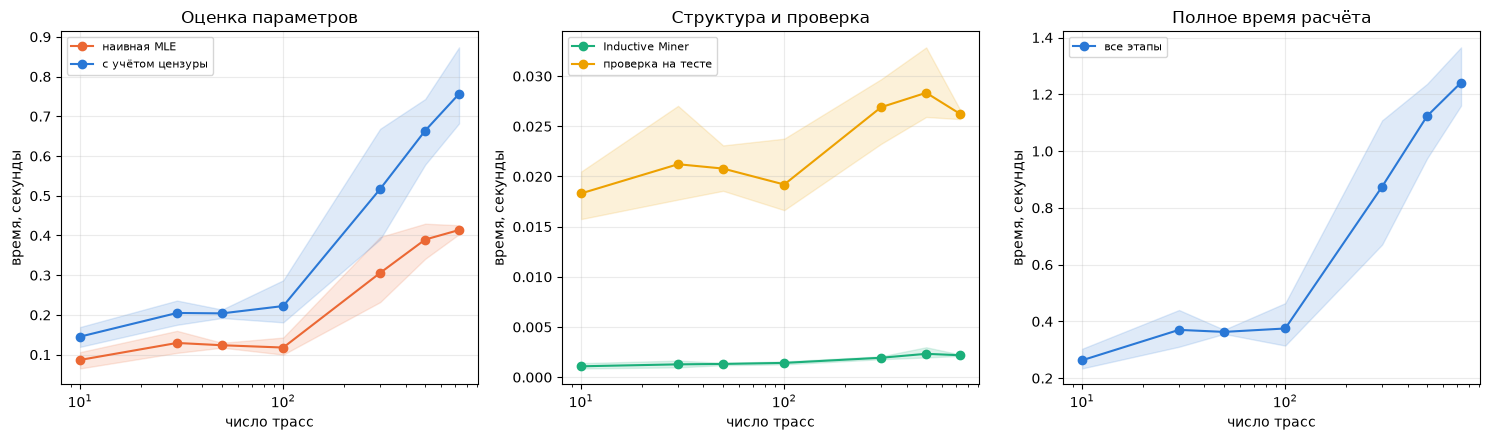

In [23]:
time_columns = ["interval_preparation_seconds", "pm_preparation_seconds",
                "discovery_seconds", "conformance_seconds", "naive_fit_seconds",
                "censor_aware_fit_seconds", "total_seconds"]
timing_summary = timings.groupby("n_traces")[time_columns].agg(["mean", "std", "count"])
print(f"Время экспериментальной ячейки: {experiment_seconds:.2f} с")
display(timing_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for metric, label, color in [
    ("naive_fit_seconds", "наивная MLE", "#eb6834"),
    ("censor_aware_fit_seconds", "с учётом цензуры", "#2a78d6")]:
    plot_band(axes[0], timings, metric, label, color)
for metric, label, color in [
    ("discovery_seconds", "Inductive Miner", "#1baf7a"),
    ("conformance_seconds", "проверка на тесте", "#eda100")]:
    plot_band(axes[1], timings, metric, label, color)
plot_band(axes[2], timings, "total_seconds", "все этапы", "#2a78d6")
for ax, title in zip(axes, ["Оценка параметров", "Структура и проверка", "Полное время расчёта"]):
    ax.set(title=title, ylabel="время, секунды")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Результаты и ограничения

Последняя ячейка печатает фактические метрики для минимального и максимального $N$
и сохраняет таблицы в `notebooks/output/sepsis_time_estimation`.

Ограничения реального журнала:

* истины нет: метрики раздела 5 измеряют устойчивость оценок и качество на отложенных
  трассах, но не близость к «настоящим» параметрам;
* цензура — обрыв записи до выписки; предполагается, что он не зависит от скрытого
  времени выбранного перехода. Для пациентов это сильное допущение;
* семейства выбраны по AIC без учёта цензуры, по всему журналу (включая тест);
* состояния — укрупнённые группы событий; одинаковые timestamp заменены на 1 минуту;
* сеть с одним токеном не содержит параллелизма (анализы и лечение в реальности
  могут идти одновременно).

Численные ограничения оптимизатора и результаты `at_boundary` сохраняются для проверки.

Документация методов: [SciPy: MLE и fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.fit.html),
[SciPy: logsf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.logsf.html),
[PM4Py: conformance](https://processintelligence.solutions/app/static/api/2.7.17/api/pm4py.conformance.html).

In [24]:
for n in (min(TRACE_COUNTS), max(TRACE_COUNTS)):
    print(f"\nN = {n}")
    for method in ("naive", "censor_aware"):
        group = results[(results.n_traces == n) & (results.method == method)]
        valid = int(group.parameter_mape.notna().sum())
        line = f"  {method}: −log L теста={group.test_nll.mean():.3f} (покрытие {group.test_coverage.mean():.1%})"
        if valid:
            line += (f"; полная оценка {valid}/{N_REPEATS}; откл. параметров={group.parameter_mape.mean():.3f}; "
                     f"откл. среднего={group.mean_time_mape.mean():.3f}; откл. CDF={group.cdf_error.mean():.3f}")
        else:
            line += "; недостаточно данных для полной оценки"
        print(line)
    miner = miner_results[miner_results.n_traces == n]
    print(f"  IM: fitness полного теста={miner.fitness_complete.mean():.3f}; "
          f"precision={miner.precision_complete.mean():.3f}")

out = OUTPUT_DIR
out.mkdir(parents=True, exist_ok=True)
results.to_csv(out / "reconstruction_metrics.csv", index=False)
miner_results.to_csv(out / "inductive_metrics.csv", index=False)
parameter_results.to_csv(out / "parameter_estimates.csv", index=False)
fit_diagnostics.to_csv(out / "fit_diagnostics.csv", index=False)
summary.to_csv(out / "summary.csv")
timings.to_csv(out / "execution_times.csv", index=False)
timing_summary.to_csv(out / "execution_time_summary.csv")
censor_probabilities.to_csv(out / "censoring_probabilities.csv", index=False)
transition_curves.to_csv(out / "transition_curves.csv", index=False)
completion_curves.to_csv(out / "completion_curves.csv", index=False)
completion_times.to_csv(out / "completion_times.csv", index=False)
aic_table.to_csv(out / "family_aic.csv", index=False)
comparison.to_csv(out / "edge_estimates.csv", index=False)
print("Рисунки сохранены:", figure_dir.resolve())
print("\nТаблицы сохранены:", out.resolve())


N = 10
  naive: −log L теста=1.062 (покрытие 54.0%); недостаточно данных для полной оценки
  censor_aware: −log L теста=1.063 (покрытие 54.0%); недостаточно данных для полной оценки
  IM: fitness полного теста=0.990; precision=0.704

N = 734
  naive: −log L теста=0.124 (покрытие 100.0%); полная оценка 5/5; откл. параметров=0.000; откл. среднего=0.000; откл. CDF=0.000
  censor_aware: −log L теста=0.124 (покрытие 100.0%); полная оценка 5/5; откл. параметров=0.000; откл. среднего=0.000; откл. CDF=0.000
  IM: fitness полного теста=1.000; precision=0.638
Рисунки сохранены: /Users/dimonzhi/Documents/proga/SurvivalProcessMining/dima/notebooks/output/sepsis_time_estimation/figures

Таблицы сохранены: /Users/dimonzhi/Documents/proga/SurvivalProcessMining/dima/notebooks/output/sepsis_time_estimation
